# DR family taxa plots

In [1]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/family")

In [3]:
taxa = read.csv('otu_id_family.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<lgl>
1,49546,Flavobacteriaceae,FALSE
2,186817,Bacillaceae,FALSE
3,31979,Clostridiaceae,FALSE
4,543,Enterobacteriaceae,FALSE
5,468,Moraxellaceae,FALSE
6,2062,Streptomycetaceae,FALSE


In [4]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")
head(taxa)

,otuid,species
,<int>,<chr>
1,49546,Flavobacteriaceae
2,186817,Bacillaceae
3,31979,Clostridiaceae
4,543,Enterobacteriaceae
5,468,Moraxellaceae
6,2062,Streptomycetaceae


In [5]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
49546,Flavobacteriaceae
186817,Bacillaceae
31979,Clostridiaceae
543,Enterobacteriaceae
468,Moraxellaceae
2062,Streptomycetaceae


In [6]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy) 

 chr [1:835, 1] "Flavobacteriaceae" "Bacillaceae" "Clostridiaceae" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:835] "49546" "186817" "31979" "543" ...
  ..$ : chr "species"


In [7]:
#read in normalized otu table
otu = read.csv('otu_normtable_family.csv',header=TRUE)
head(otu)

,X,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,73419.08,74875.53,70977.46,55925.54,63761.53,37543.556,37951.847,67396.06,72716.41,⋯,72882.50,75847.66,61831.06,61659.47,73040.44,50987.70,72442.06,66996.49,68911.71,1811483.6
2,186817,60501.36,57370.95,41300.86,50320.45,54331.27,35512.869,15924.892,60336.29,38675.85,⋯,65105.98,60800.91,67882.43,58758.79,61682.48,54608.48,68603.04,62890.65,62678.90,1449031.9
3,31979,31232.28,22261.65,18194.76,15023.12,18499.43,10252.552,3956.720,22066.11,12764.54,⋯,27938.21,26808.41,27347.82,20416.44,24238.64,24621.30,27956.11,25897.35,24229.44,593850.0
4,543,24700.28,25301.88,27626.63,30119.99,31849.37,24180.164,23053.039,26004.84,27736.35,⋯,24501.28,30007.32,37213.90,27728.53,40788.82,28574.48,28338.72,24614.70,31625.70,801346.0
5,468,23011.68,13648.85,10677.09,12220.58,13533.10,9215.606,5541.829,17931.59,11483.24,⋯,14804.49,16091.51,19567.48,19058.38,19146.28,17818.98,18066.74,17753.53,15540.45,414338.3
6,2062,19057.07,28857.16,23106.09,39132.39,33749.03,49132.955,65047.517,24484.63,28193.96,⋯,17725.27,26829.95,16644.71,32212.86,22840.74,22436.96,21834.43,21750.79,24312.55,822641.4


In [8]:
# rename first col as species
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,73419.08,74875.53,70977.46,55925.54,63761.53,37543.556,37951.847,67396.06,72716.41,⋯,72882.50,75847.66,61831.06,61659.47,73040.44,50987.70,72442.06,66996.49,68911.71,1811483.6
2,186817,60501.36,57370.95,41300.86,50320.45,54331.27,35512.869,15924.892,60336.29,38675.85,⋯,65105.98,60800.91,67882.43,58758.79,61682.48,54608.48,68603.04,62890.65,62678.90,1449031.9
3,31979,31232.28,22261.65,18194.76,15023.12,18499.43,10252.552,3956.720,22066.11,12764.54,⋯,27938.21,26808.41,27347.82,20416.44,24238.64,24621.30,27956.11,25897.35,24229.44,593850.0
4,543,24700.28,25301.88,27626.63,30119.99,31849.37,24180.164,23053.039,26004.84,27736.35,⋯,24501.28,30007.32,37213.90,27728.53,40788.82,28574.48,28338.72,24614.70,31625.70,801346.0
5,468,23011.68,13648.85,10677.09,12220.58,13533.10,9215.606,5541.829,17931.59,11483.24,⋯,14804.49,16091.51,19567.48,19058.38,19146.28,17818.98,18066.74,17753.53,15540.45,414338.3
6,2062,19057.07,28857.16,23106.09,39132.39,33749.03,49132.955,65047.517,24484.63,28193.96,⋯,17725.27,26829.95,16644.71,32212.86,22840.74,22436.96,21834.43,21750.79,24312.55,822641.4


[1] 836  30

In [9]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,73419.08,74875.53,70977.46,55925.54,63761.53,37543.556,37951.847,67396.06,72716.41,⋯,72882.50,75847.66,61831.06,61659.47,73040.44,50987.70,72442.06,66996.49,68911.71,1811483.6
2,186817,60501.36,57370.95,41300.86,50320.45,54331.27,35512.869,15924.892,60336.29,38675.85,⋯,65105.98,60800.91,67882.43,58758.79,61682.48,54608.48,68603.04,62890.65,62678.90,1449031.9
3,31979,31232.28,22261.65,18194.76,15023.12,18499.43,10252.552,3956.720,22066.11,12764.54,⋯,27938.21,26808.41,27347.82,20416.44,24238.64,24621.30,27956.11,25897.35,24229.44,593850.0
4,543,24700.28,25301.88,27626.63,30119.99,31849.37,24180.164,23053.039,26004.84,27736.35,⋯,24501.28,30007.32,37213.90,27728.53,40788.82,28574.48,28338.72,24614.70,31625.70,801346.0
5,468,23011.68,13648.85,10677.09,12220.58,13533.10,9215.606,5541.829,17931.59,11483.24,⋯,14804.49,16091.51,19567.48,19058.38,19146.28,17818.98,18066.74,17753.53,15540.45,414338.3
6,2062,19057.07,28857.16,23106.09,39132.39,33749.03,49132.955,65047.517,24484.63,28193.96,⋯,17725.27,26829.95,16644.71,32212.86,22840.74,22436.96,21834.43,21750.79,24312.55,822641.4


In [10]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
column_list <- readLines("DR_column_order.txt")
otu_table <- otu_table[, column_list]
head(otu_table)

,otu,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,49546,74875.53,70977.46,71734.56,62309.86,72264.68,67170.05,75847.66,73419.08,67396.06,⋯,37543.556,37951.847,52097.651,72882.50,61659.47,72442.06,66996.49,68911.71,50172.99,70788.59
2,186817,57370.95,41300.86,60777.69,53197.08,56299.39,54211.89,60800.91,60501.36,60336.29,⋯,35512.869,15924.892,22781.824,65105.98,58758.79,68603.04,62890.65,62678.90,37273.26,45691.53
3,31979,22261.65,18194.76,25064.88,18018.14,25791.19,24087.62,26808.41,31232.28,22066.11,⋯,10252.552,3956.720,19728.519,27938.21,20416.44,27956.11,25897.35,24229.44,16856.98,22183.83
4,543,25301.88,27626.63,27124.44,33699.32,27961.02,32051.28,30007.32,24700.28,26004.84,⋯,24180.164,23053.039,11088.317,24501.28,27728.53,28338.72,24614.70,31625.70,32166.43,23707.73
5,468,13648.85,10677.09,15034.81,13745.23,15645.98,15888.00,16091.51,23011.68,17931.59,⋯,9215.606,5541.829,6431.429,14804.49,19058.38,18066.74,17753.53,15540.45,15221.02,15626.34
6,2062,28857.16,23106.09,23376.03,39327.40,28323.86,24952.81,26829.95,19057.07,24484.63,⋯,49132.955,65047.517,28785.858,17725.27,32212.86,21834.43,21750.79,24312.55,28397.10,24833.38


In [11]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49546,74875.53,70977.46,71734.56,62309.86,72264.68,67170.05,75847.66,73419.08,67396.06,72716.41,⋯,37543.556,37951.847,52097.651,72882.50,61659.47,72442.06,66996.49,68911.71,50172.99,70788.59
186817,57370.95,41300.86,60777.69,53197.08,56299.39,54211.89,60800.91,60501.36,60336.29,38675.85,⋯,35512.869,15924.892,22781.824,65105.98,58758.79,68603.04,62890.65,62678.90,37273.26,45691.53
31979,22261.65,18194.76,25064.88,18018.14,25791.19,24087.62,26808.41,31232.28,22066.11,12764.54,⋯,10252.552,3956.720,19728.519,27938.21,20416.44,27956.11,25897.35,24229.44,16856.98,22183.83
543,25301.88,27626.63,27124.44,33699.32,27961.02,32051.28,30007.32,24700.28,26004.84,27736.35,⋯,24180.164,23053.039,11088.317,24501.28,27728.53,28338.72,24614.70,31625.70,32166.43,23707.73
468,13648.85,10677.09,15034.81,13745.23,15645.98,15888.00,16091.51,23011.68,17931.59,11483.24,⋯,9215.606,5541.829,6431.429,14804.49,19058.38,18066.74,17753.53,15540.45,15221.02,15626.34
2062,28857.16,23106.09,23376.03,39327.40,28323.86,24952.81,26829.95,19057.07,24484.63,28193.96,⋯,49132.955,65047.517,28785.858,17725.27,32212.86,21834.43,21750.79,24312.55,28397.10,24833.38


In [12]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,139792.000,301955.000,48554.00,72316.00,137799.00,50856.00,92844.00,1169015.00,86830.000,185749.000,⋯,393463.00,826442.00,292470.00,408795.00,438862.000,154206.00,147351.00,108298.00,90467.00,549905.00
49546,74875.529,70977.464,71734.56,62309.86,72264.68,67170.05,75847.66,73419.08,67396.061,72716.408,⋯,37543.56,37951.85,52097.65,72882.50,61659.474,72442.06,66996.49,68911.71,50172.99,70788.59
186817,57370.951,41300.856,60777.69,53197.08,56299.39,54211.89,60800.91,60501.36,60336.289,38675.848,⋯,35512.87,15924.89,22781.82,65105.98,58758.790,68603.04,62890.65,62678.90,37273.26,45691.53
41294,6738.583,7650.147,35465.67,15003.60,15188.79,19918.99,15628.37,12009.26,8614.534,8086.181,⋯,19084.39,20185.32,196649.23,11661.10,9087.139,11471.67,53871.37,28366.17,189925.61,134292.29
2062,28857.159,23106.092,23376.03,39327.40,28323.86,24952.81,26829.95,19057.07,24484.625,28193.961,⋯,49132.96,65047.52,28785.86,17725.27,32212.860,21834.43,21750.79,24312.55,28397.10,24833.38
543,25301.877,27626.633,27124.44,33699.32,27961.02,32051.28,30007.32,24700.28,26004.837,27736.354,⋯,24180.16,23053.04,11088.32,24501.28,27728.534,28338.72,24614.70,31625.70,32166.43,23707.73


In [13]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49546,74875.529,70977.464,71734.56,62309.86,72264.68,67170.05,75847.66,73419.08,67396.061,72716.408,⋯,37543.56,37951.85,52097.65,72882.50,61659.474,72442.06,66996.49,68911.71,50172.99,70788.59
186817,57370.951,41300.856,60777.69,53197.08,56299.39,54211.89,60800.91,60501.36,60336.289,38675.848,⋯,35512.87,15924.89,22781.82,65105.98,58758.790,68603.04,62890.65,62678.90,37273.26,45691.53
41294,6738.583,7650.147,35465.67,15003.60,15188.79,19918.99,15628.37,12009.26,8614.534,8086.181,⋯,19084.39,20185.32,196649.23,11661.10,9087.139,11471.67,53871.37,28366.17,189925.61,134292.29
2062,28857.159,23106.092,23376.03,39327.40,28323.86,24952.81,26829.95,19057.07,24484.625,28193.961,⋯,49132.96,65047.52,28785.86,17725.27,32212.860,21834.43,21750.79,24312.55,28397.10,24833.38
543,25301.877,27626.633,27124.44,33699.32,27961.02,32051.28,30007.32,24700.28,26004.837,27736.354,⋯,24180.16,23053.04,11088.32,24501.28,27728.534,28338.72,24614.70,31625.70,32166.43,23707.73
31979,22261.646,18194.764,25064.88,18018.14,25791.19,24087.62,26808.41,31232.28,22066.106,12764.537,⋯,10252.55,3956.72,19728.52,27938.21,20416.441,27956.11,25897.35,24229.44,16856.98,22183.83


[1] 835  28

In [14]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,122021_Coralina_2021_Baya_013_DLAB_S43,122021_Coralina_2021_Baya_015_DLAB_S44
49546,74875.529,70977.464,71734.56,62309.86,72264.68,67170.05,75847.66,73419.08,67396.061,72716.408,⋯,37543.56,37951.85,52097.65,72882.50,61659.474,72442.06,66996.49,68911.71,50172.99,70788.59
186817,57370.951,41300.856,60777.69,53197.08,56299.39,54211.89,60800.91,60501.36,60336.289,38675.848,⋯,35512.87,15924.89,22781.82,65105.98,58758.790,68603.04,62890.65,62678.90,37273.26,45691.53
41294,6738.583,7650.147,35465.67,15003.60,15188.79,19918.99,15628.37,12009.26,8614.534,8086.181,⋯,19084.39,20185.32,196649.23,11661.10,9087.139,11471.67,53871.37,28366.17,189925.61,134292.29
2062,28857.159,23106.092,23376.03,39327.40,28323.86,24952.81,26829.95,19057.07,24484.625,28193.961,⋯,49132.96,65047.52,28785.86,17725.27,32212.860,21834.43,21750.79,24312.55,28397.10,24833.38
543,25301.877,27626.633,27124.44,33699.32,27961.02,32051.28,30007.32,24700.28,26004.837,27736.354,⋯,24180.16,23053.04,11088.32,24501.28,27728.534,28338.72,24614.70,31625.70,32166.43,23707.73
31979,22261.646,18194.764,25064.88,18018.14,25791.19,24087.62,26808.41,31232.28,22066.106,12764.537,⋯,10252.55,3956.72,19728.52,27938.21,20416.441,27956.11,25897.35,24229.44,16856.98,22183.83


In [15]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/kraken_bracken/DR_metadata_all.csv', header=TRUE)
head(metadata)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [16]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [17]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)
TAX=tax_table(taxonomy)
SAMP=sample_data(metadata)

In [18]:
# Create phyloseq object
DR_f_all = phyloseq(OTU, SAMP, TAX)
DR_f_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 835 taxa and 28 samples ]
sample_data() Sample Data:       [ 28 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 835 taxa by 1 taxonomic ranks ]

### SSID plots

In [19]:
DR_ssid <- subset_samples(DR_f_all, Species == "SSID")
DR_ssid

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 835 taxa and 6 samples ]
sample_data() Sample Data:       [ 6 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 835 taxa by 1 taxonomic ranks ]

In [20]:
#now prune to top 50 families
DR_ssid_50 = prune_taxa(names(sort(taxa_sums(DR_ssid),TRUE)[1:50]), DR_ssid)

In [21]:
sample_data(DR_ssid_50)$Type_s <- factor(sample_data(DR_ssid_50)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

In [22]:
#https://rampgenerator.com/
colors_50 <- c("#4477AA",
  "#4881B2",
  "#4C8CBB",
  "#5096C3",
  "#55A1CB",
  "#59ABD4",
  "#5DB5DC",
  "#61C0E4",
  "#65CAED",
  "#5FC5DB",
  "#57BDC4",
  "#4EB4AD",
  "#46AC96",
  "#3EA47F",
  "#359B68",
  "#2D9352",
  "#258B3B",
  "#308C34",
  "#459236",
  "#5A9939",
  "#6E9F3B",
  "#83A53D",
  "#98AB3F",
  "#ADB241",
  "#C2B843",
  "#CEB647",
  "#D2AB4D",
  "#D6A154",
  "#DB975A",
  "#DF8C60",
  "#E38266",
  "#E7776D",
  "#EB6D73",
  "#EB6477",
  "#E35E77",
  "#DB5777",
  "#D25177",
  "#CA4B77",
  "#C24577",
  "#B93E77",
  "#B13877",
  "#AA3678",
  "#AC4681",
  "#AF5789",
  "#B16891",
  "#B3789A",
  "#B589A2",
  "#B79AAA",
  "#B9AAB3",
  "#BBBBBB")

In [23]:
#shuffle colors
set.seed(234)
shuffled_colors <- sample(colors_50)

In [43]:
options(repr.plot.width=10, repr.plot.height=15)

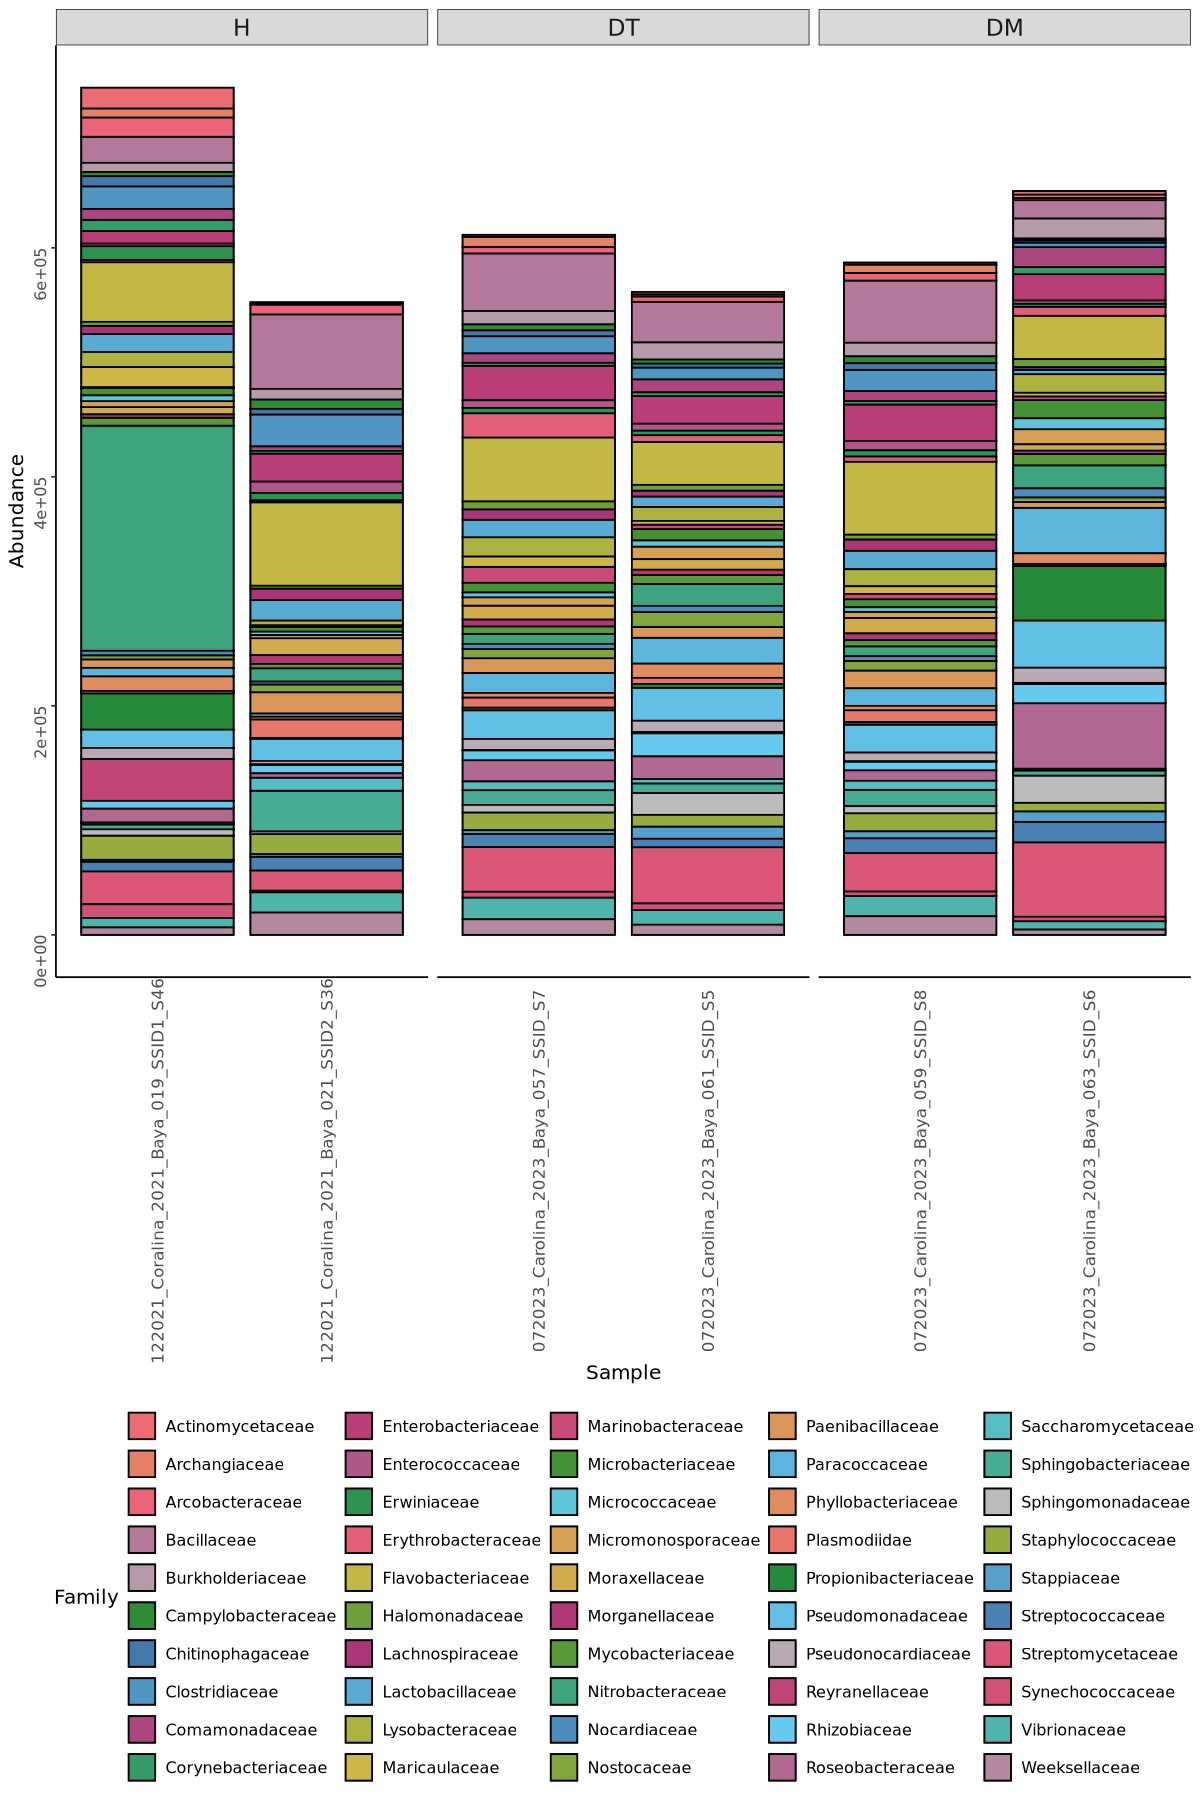

In [45]:
#taxa plot top 50 families
DR_ssid_50_plot<-plot_bar(DR_ssid_50,fill='species')+
facet_grid(~Type_s, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Abundance", fill = "Family")
DR_ssid_50_plot

In [46]:
ggsave(filename = "DR_ssid_top_50_families_bar.png", plot = DR_ssid_50_plot, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

now facet by colony

In [26]:
sample_data(DR_ssid_50)$Tag_s <- factor(sample_data(DR_ssid_50)$Tag, 
                                      levels = c("SSID-1", "SSID-2"))

In [40]:
options(repr.plot.width=10, repr.plot.height=15)

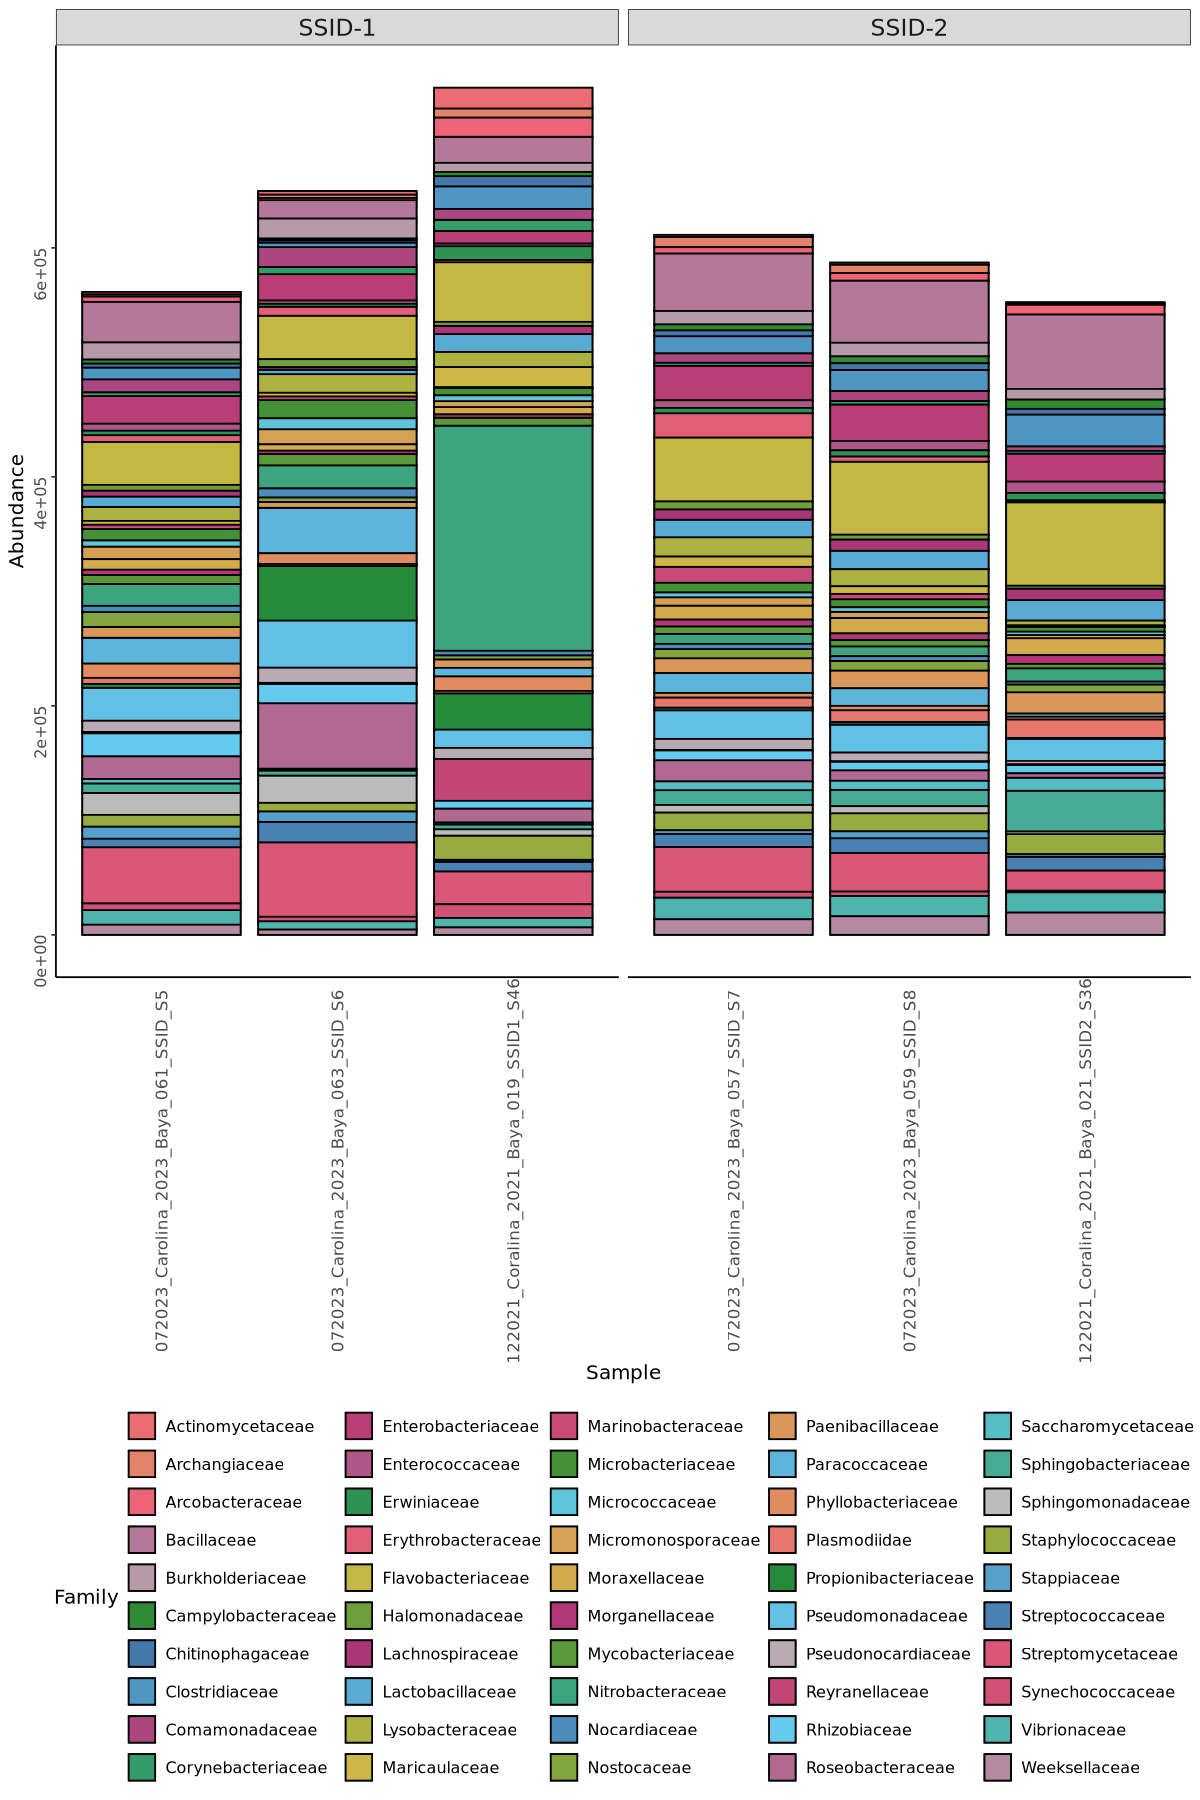

In [47]:
#taxa plot top 50 families by colony
DR_ssid_50_plot_c<-plot_bar(DR_ssid_50,fill='species')+
facet_grid(~Tag_s, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Abundance", fill = "Family")
DR_ssid_50_plot_c

In [48]:
ggsave(filename = "DR_ssid_top_50_families_bar_colony.png", plot = DR_ssid_50_plot_c, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

In [43]:
#now do relative abundance plot and then prune to top 50
DR_ssid_rel <- transform_sample_counts(DR_ssid, function(x) x / sum(x))
DR_ssid_rel_50 = prune_taxa(names(sort(taxa_sums(DR_ssid_rel),TRUE)[1:50]), DR_ssid_rel)

In [55]:
sample_data(DR_ssid_rel_50)$Type_sr <- factor(sample_data(DR_ssid_rel_50)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

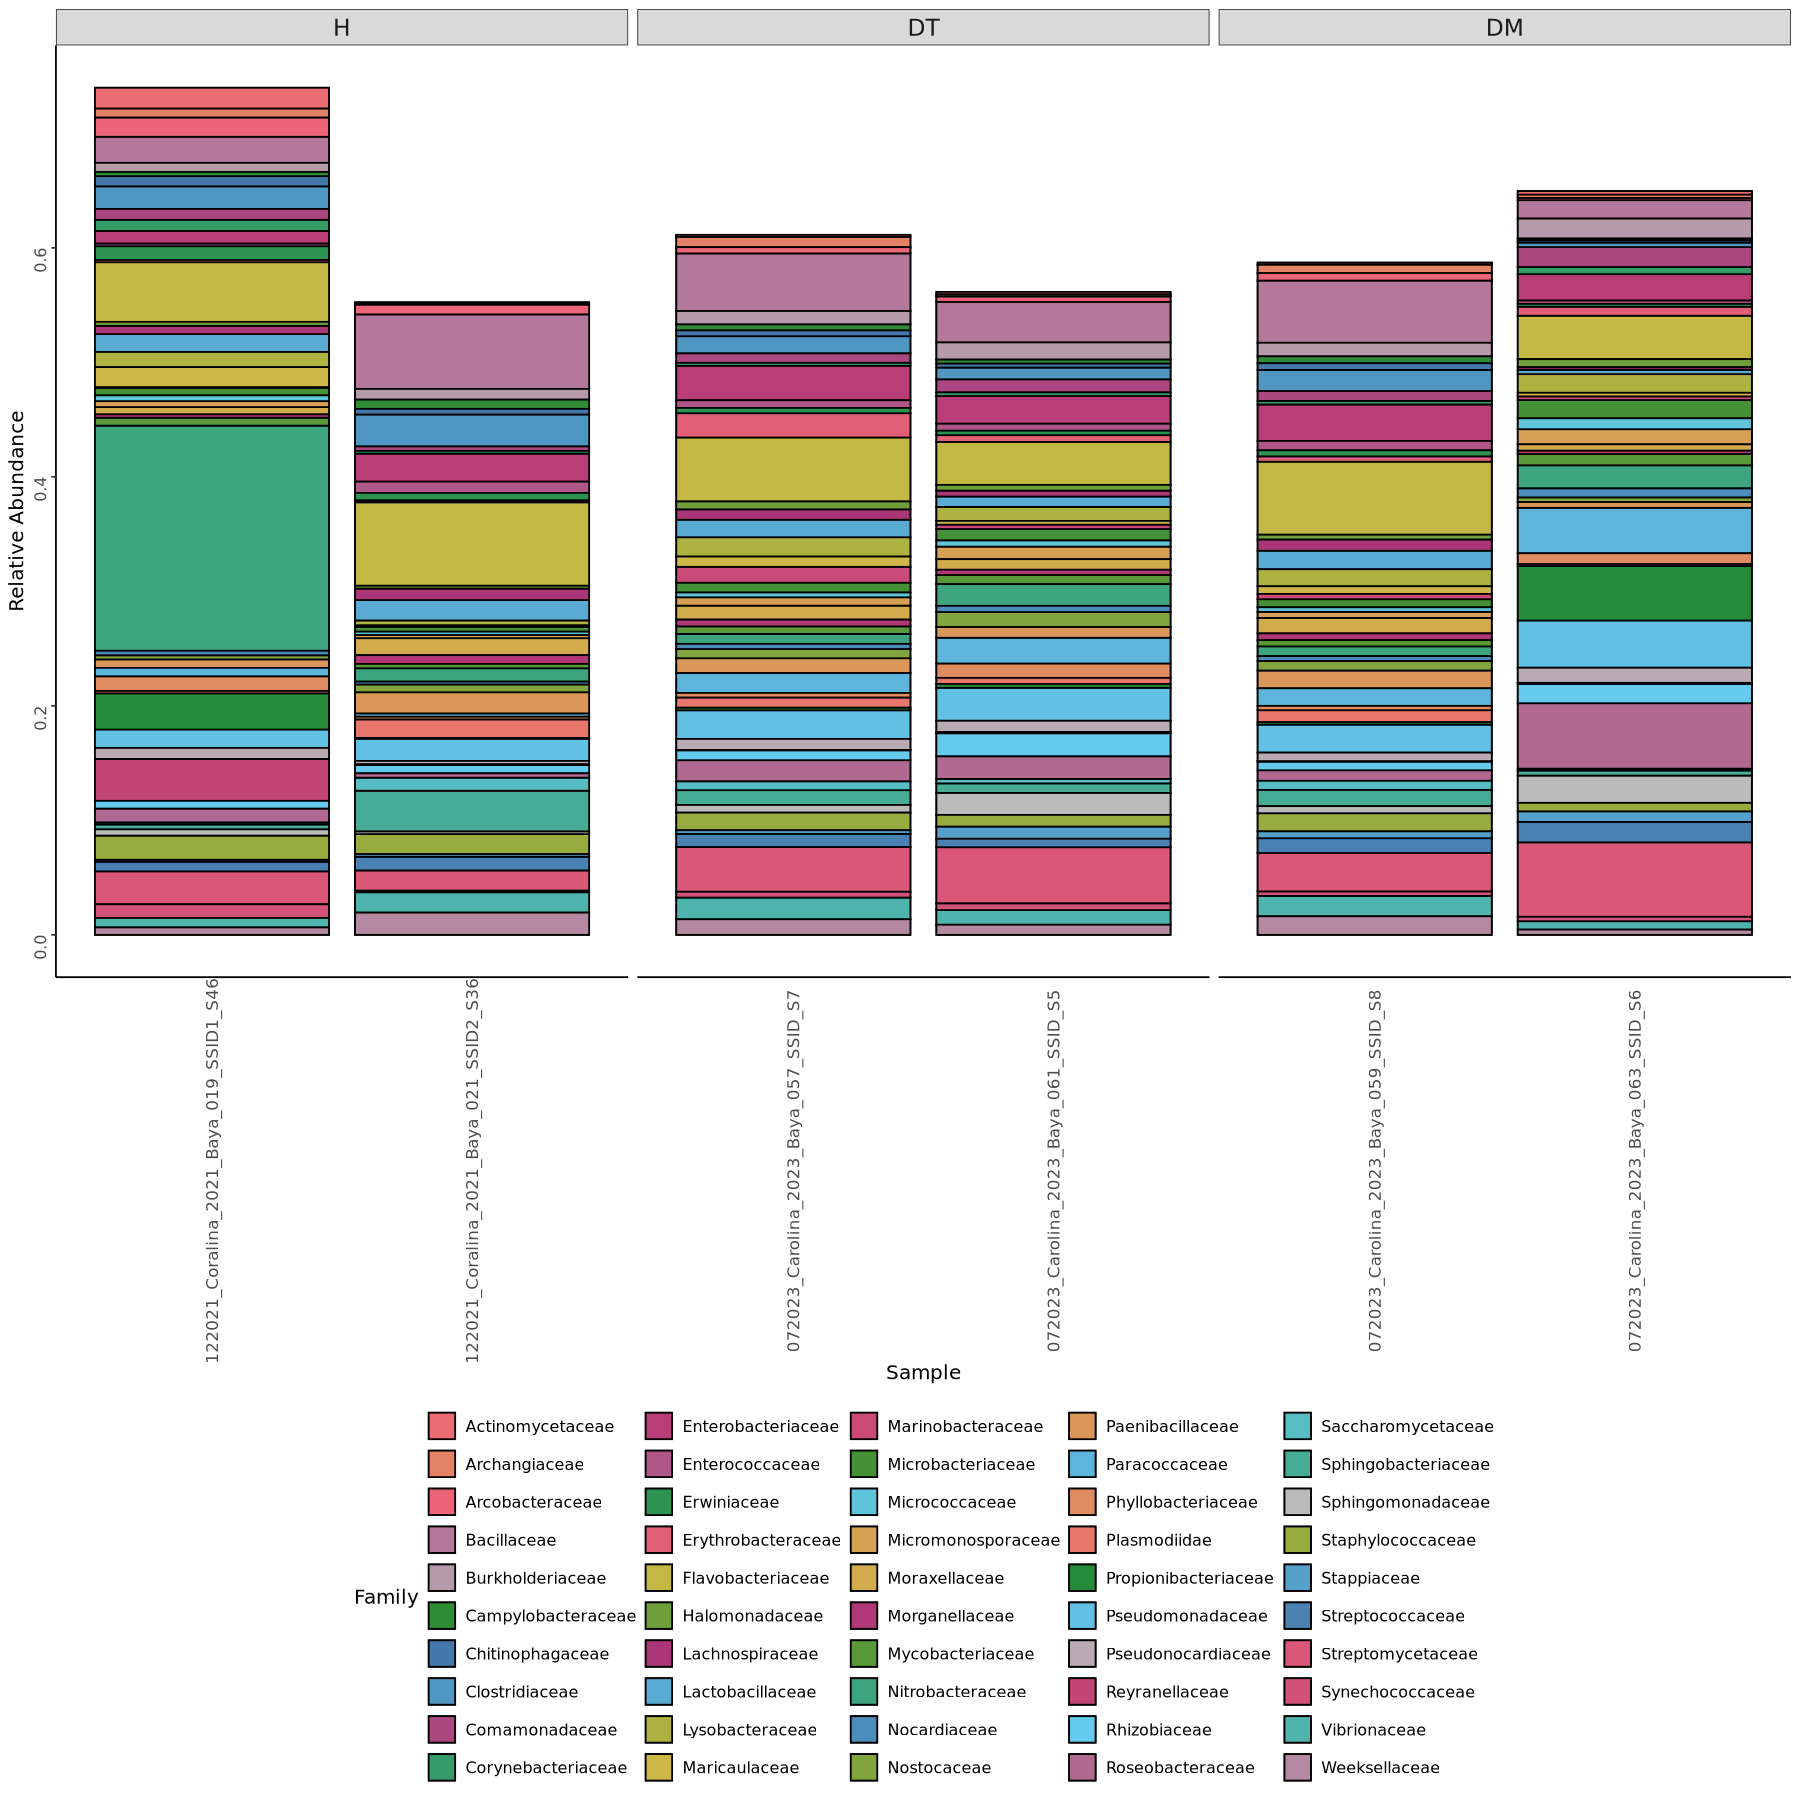

In [35]:
#taxa rel plot top 50 families
DR_ssid_50_rel_plot<-plot_bar(DR_ssid_rel_50,fill='species')+
facet_grid(~Type_sr, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_ssid_50_rel_plot

In [49]:
ggsave(filename = "DR_ssid_rel_top_50_families_bar.png", plot = DR_ssid_50_rel_plot, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

In [59]:
sample_data(DR_ssid_rel_50)$Tag_sr <- factor(sample_data(DR_ssid_rel_50)$Tag, 
                                      levels = c("SSID-2", "SSID-1"))

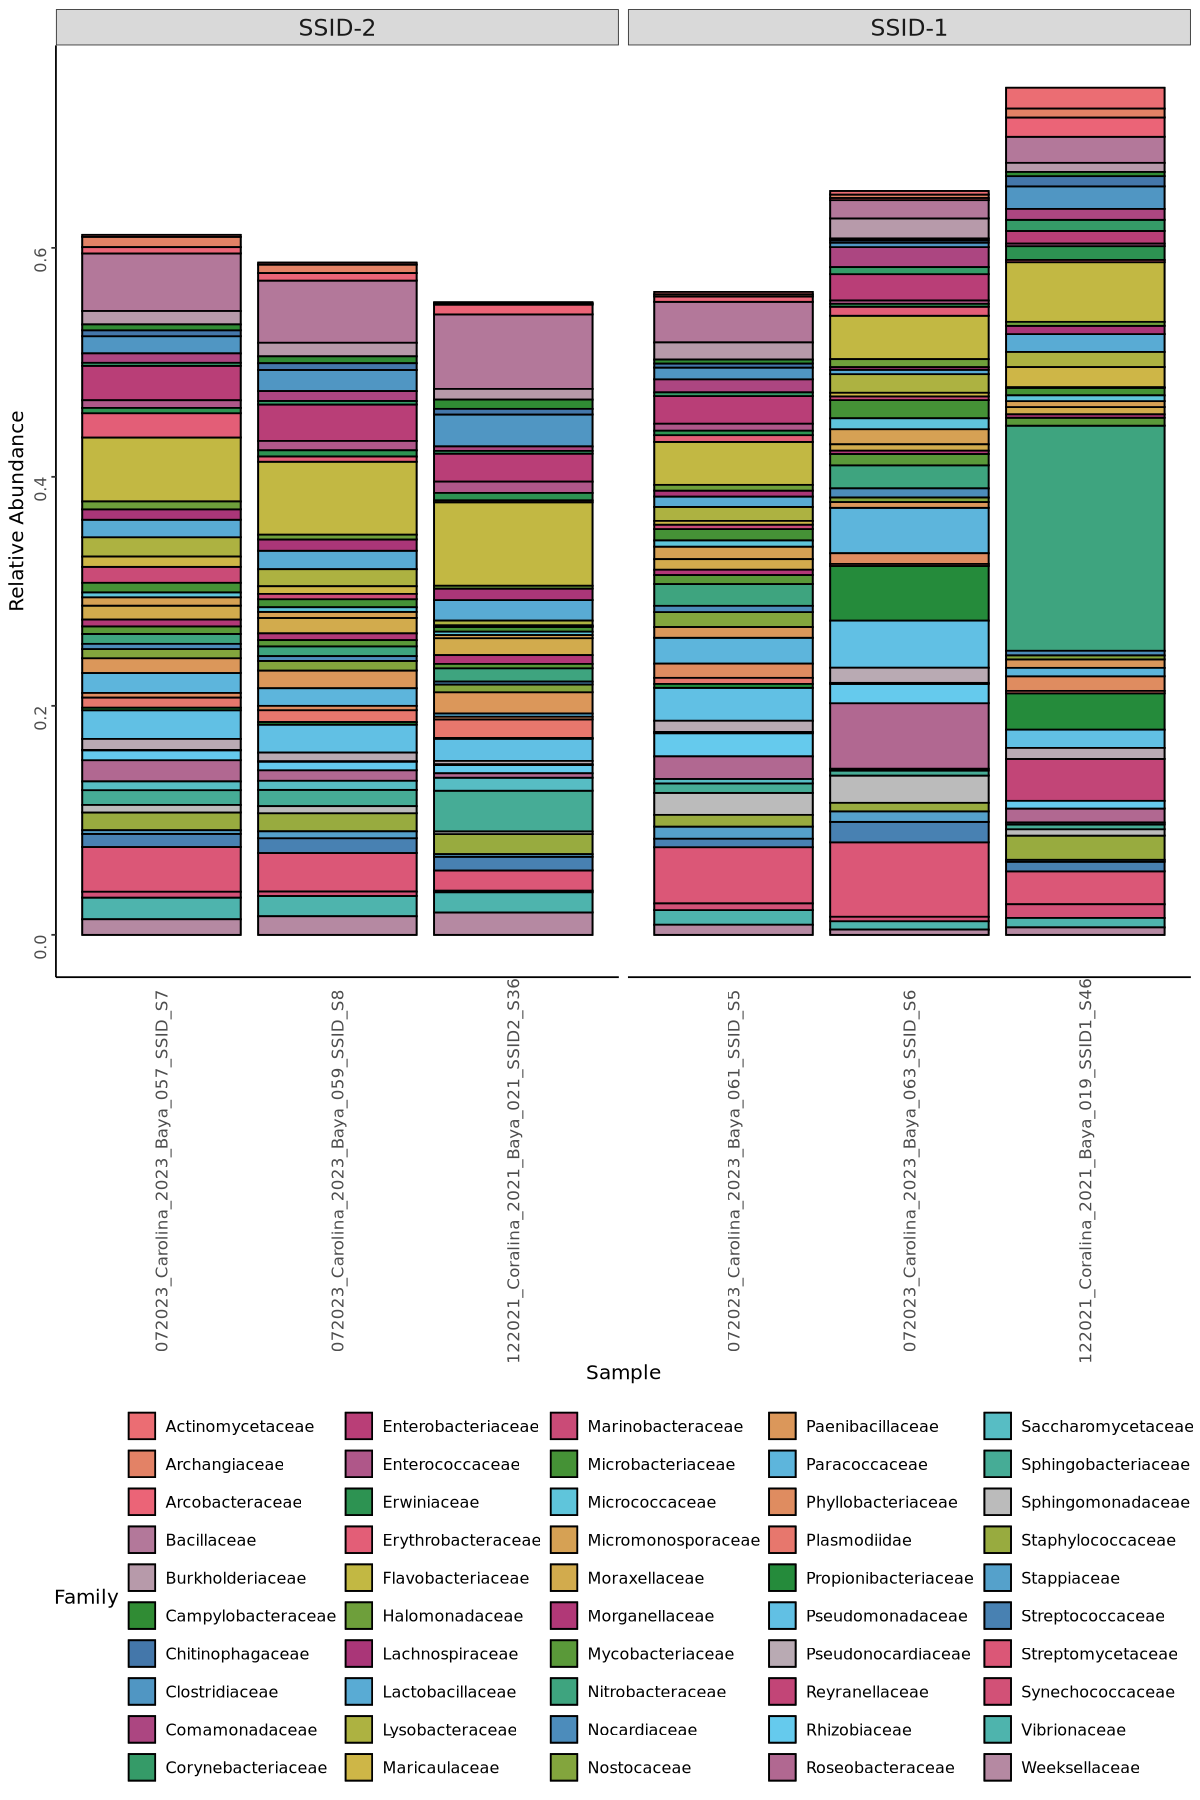

In [60]:
#taxa rel plot top 50 families
DR_ssid_50_rel_plot1<-plot_bar(DR_ssid_rel_50,fill='species')+
facet_grid(~Tag_sr, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_ssid_50_rel_plot1

In [51]:
ggsave(filename = "DR_ssid_rel_top_50_families_bar_colony.png", plot = DR_ssid_50_rel_plot1, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

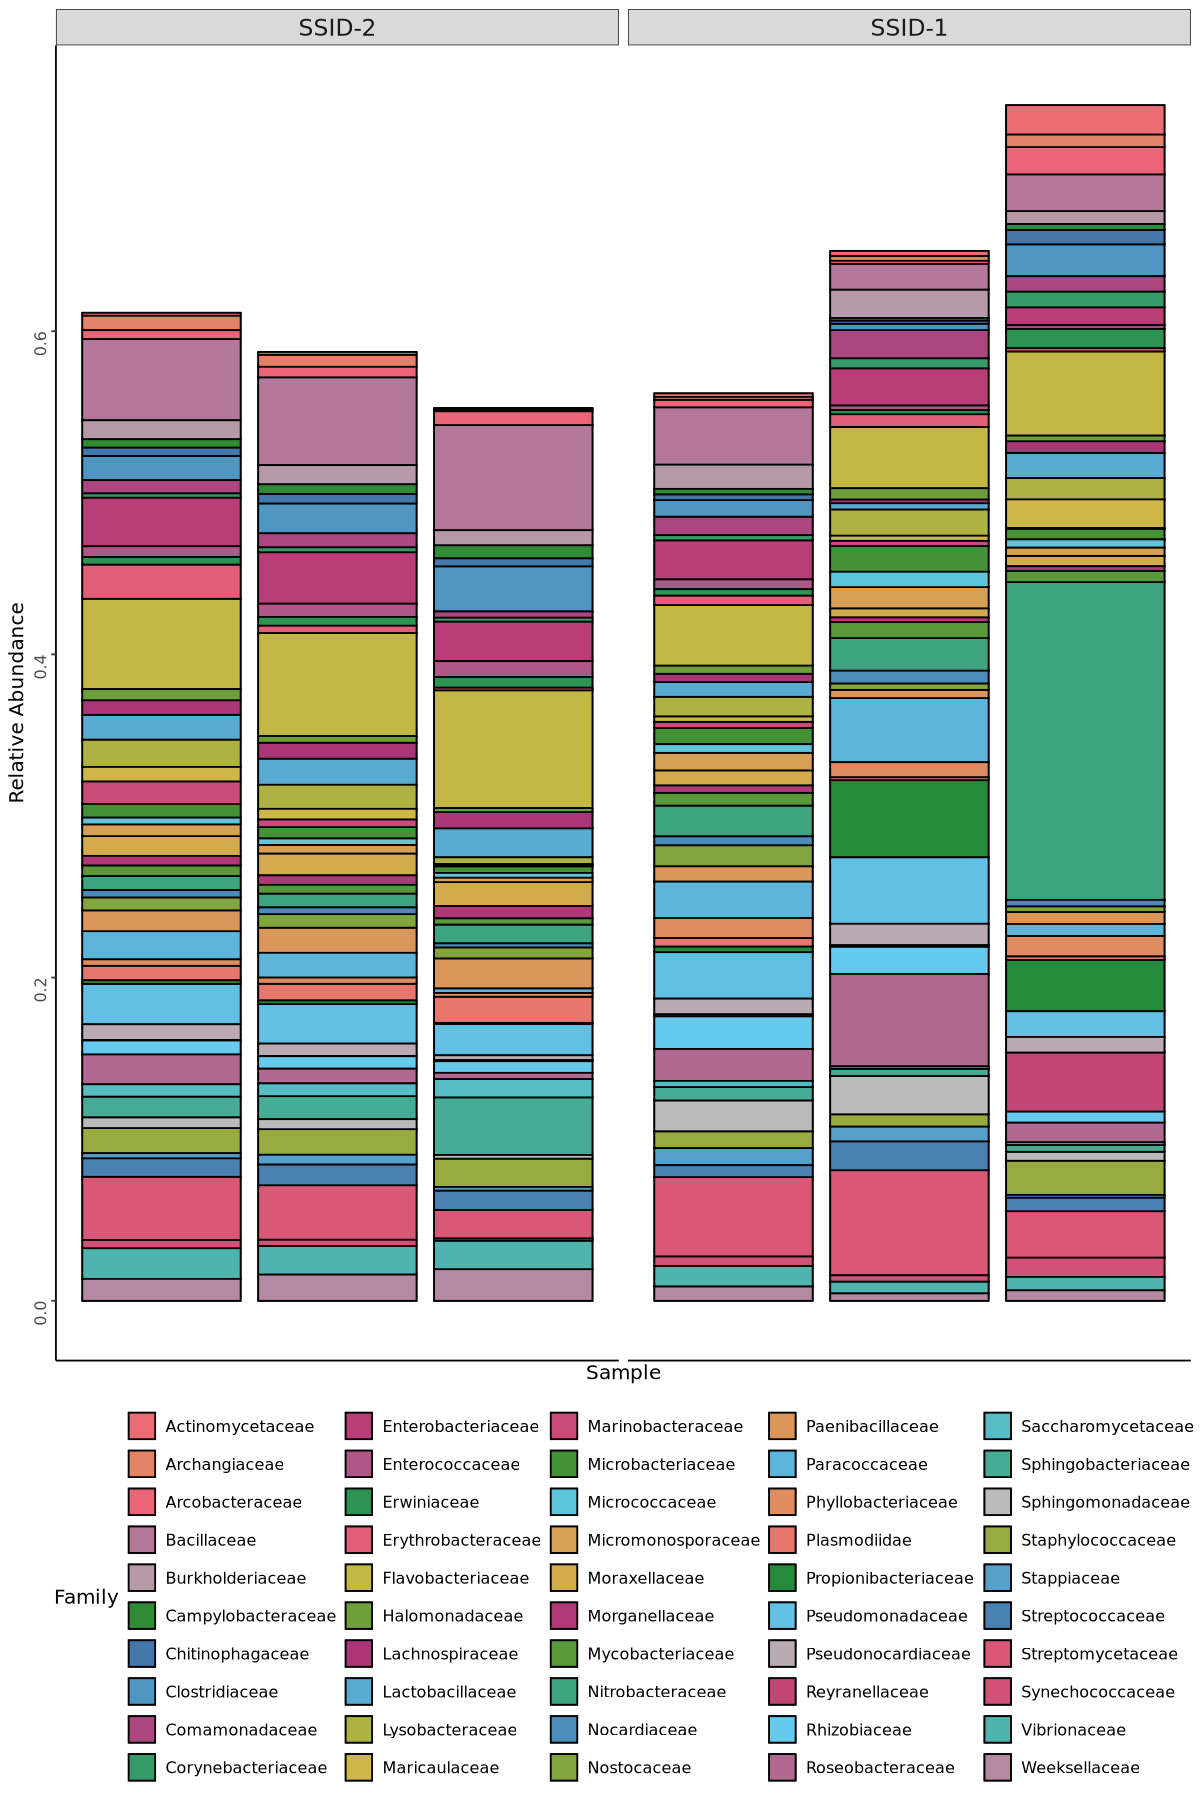

In [62]:
#taxa rel plot top 50 families
DR_ssid_50_rel_plot2<-plot_bar(DR_ssid_rel_50,fill='species')+
facet_grid(~Tag_sr, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          #axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.text.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_ssid_50_rel_plot2

In [63]:
ggsave(filename = "DR_ssid_rel_top_50_families_bar_colony_nolabels.png", plot = DR_ssid_50_rel_plot2, 
      width = 10,
      height = 12,
      units = "in",
      dpi = 300)

#### make a heat map with taxonomy (let's start with the top 50 families)

In [20]:
##load additional packages
library(tidyverse)
library(magrittr)
library(pheatmap)
library(RColorBrewer)
library(DESeq2)
library(ggplot2)
library(apeglm)
library(ggpicrust2)
library(ggh4x)
library(dplyr)
library(tidyr)
library(tibble)

In [ ]:
#last step was pruning the phyloseq object for the top 50 families in just SSIDs
#DR_ssid_50

In [22]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
SSID_50_otu_mat <- as(otu_table(DR_ssid_50), "matrix")
if (!taxa_are_rows(DR_ssid_50)) {
  SSID_50_otu_mat <- t(SSID_50_otu_mat)
}

In [23]:
head(SSID_50_otu_mat)

,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36
49546,55925.541,63761.533,37543.56,37951.85,52097.65,72882.50
186817,50320.449,54331.273,35512.87,15924.89,22781.82,65105.98
41294,8695.267,8582.478,19084.39,20185.32,196649.23,11661.10
2062,39132.391,33749.025,49132.96,65047.52,28785.86,17725.27
543,30119.993,31849.367,24180.16,23053.04,11088.32,24501.28
31979,15023.121,18499.427,10252.55,3956.72,19728.52,27938.21


In [24]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
SSID_50_tax_mat <- as(tax_table(DR_ssid_50), "matrix")
rownames(SSID_50_otu_mat) <- SSID_50_tax_mat[, "species"] 

In [25]:
head(SSID_50_otu_mat)

,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36
Flavobacteriaceae,55925.541,63761.533,37543.56,37951.85,52097.65,72882.50
Bacillaceae,50320.449,54331.273,35512.87,15924.89,22781.82,65105.98
Nitrobacteraceae,8695.267,8582.478,19084.39,20185.32,196649.23,11661.10
Streptomycetaceae,39132.391,33749.025,49132.96,65047.52,28785.86,17725.27
Enterobacteriaceae,30119.993,31849.367,24180.16,23053.04,11088.32,24501.28
Clostridiaceae,15023.121,18499.427,10252.55,3956.72,19728.52,27938.21


In [26]:
#turn abundances into log values
SSID_50_log_counts <- log10(SSID_50_otu_mat + 1)

In [21]:
colors <- colorRampPalette(brewer.pal(n = 9, name = "YlGnBu"))(50)

In [28]:
options(repr.plot.width=10, repr.plot.height=10)

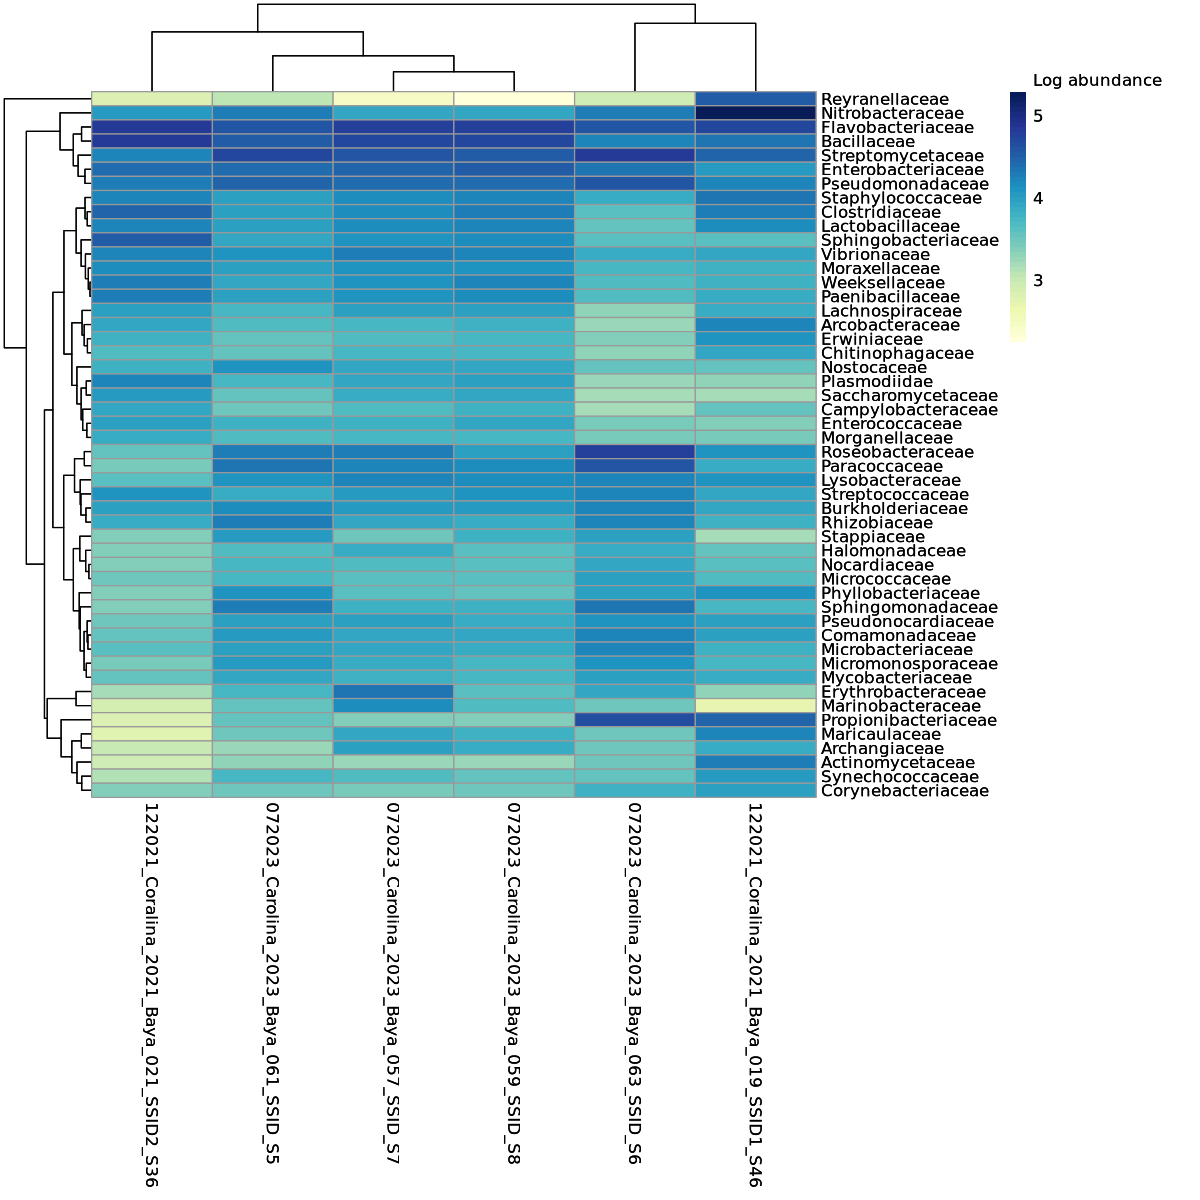

In [29]:
SSID_50_log_plot <- pheatmap(SSID_50_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 10,
         legend_breaks = c(1, 2, 3, 4, 5, max(SSID_50_log_counts)),
         legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
SSID_50_log_plot

In [30]:
ggsave(filename = "ssid_50_log_heatmap.png", plot = SSID_50_log_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [22]:
#do top 100 - I think that the lack of zeros is maybe messing a little with the data?
#now prune to top 100 families
DR_ssid_100 = prune_taxa(names(sort(taxa_sums(DR_ssid),TRUE)[1:100]), DR_ssid)

In [23]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
SSID_100_otu_mat <- as(otu_table(DR_ssid_100), "matrix")
if (!taxa_are_rows(DR_ssid_100)) {
  SSID_100_otu_mat <- t(SSID_100_otu_mat)
}

In [24]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
SSID_100_tax_mat <- as(tax_table(DR_ssid_100), "matrix")
rownames(SSID_100_otu_mat) <- SSID_100_tax_mat[, "species"] 

In [25]:
#turn abundances into log values
SSID_100_log_counts <- log10(SSID_100_otu_mat + 1)

In [26]:
options(repr.plot.width=15, repr.plot.height=15)

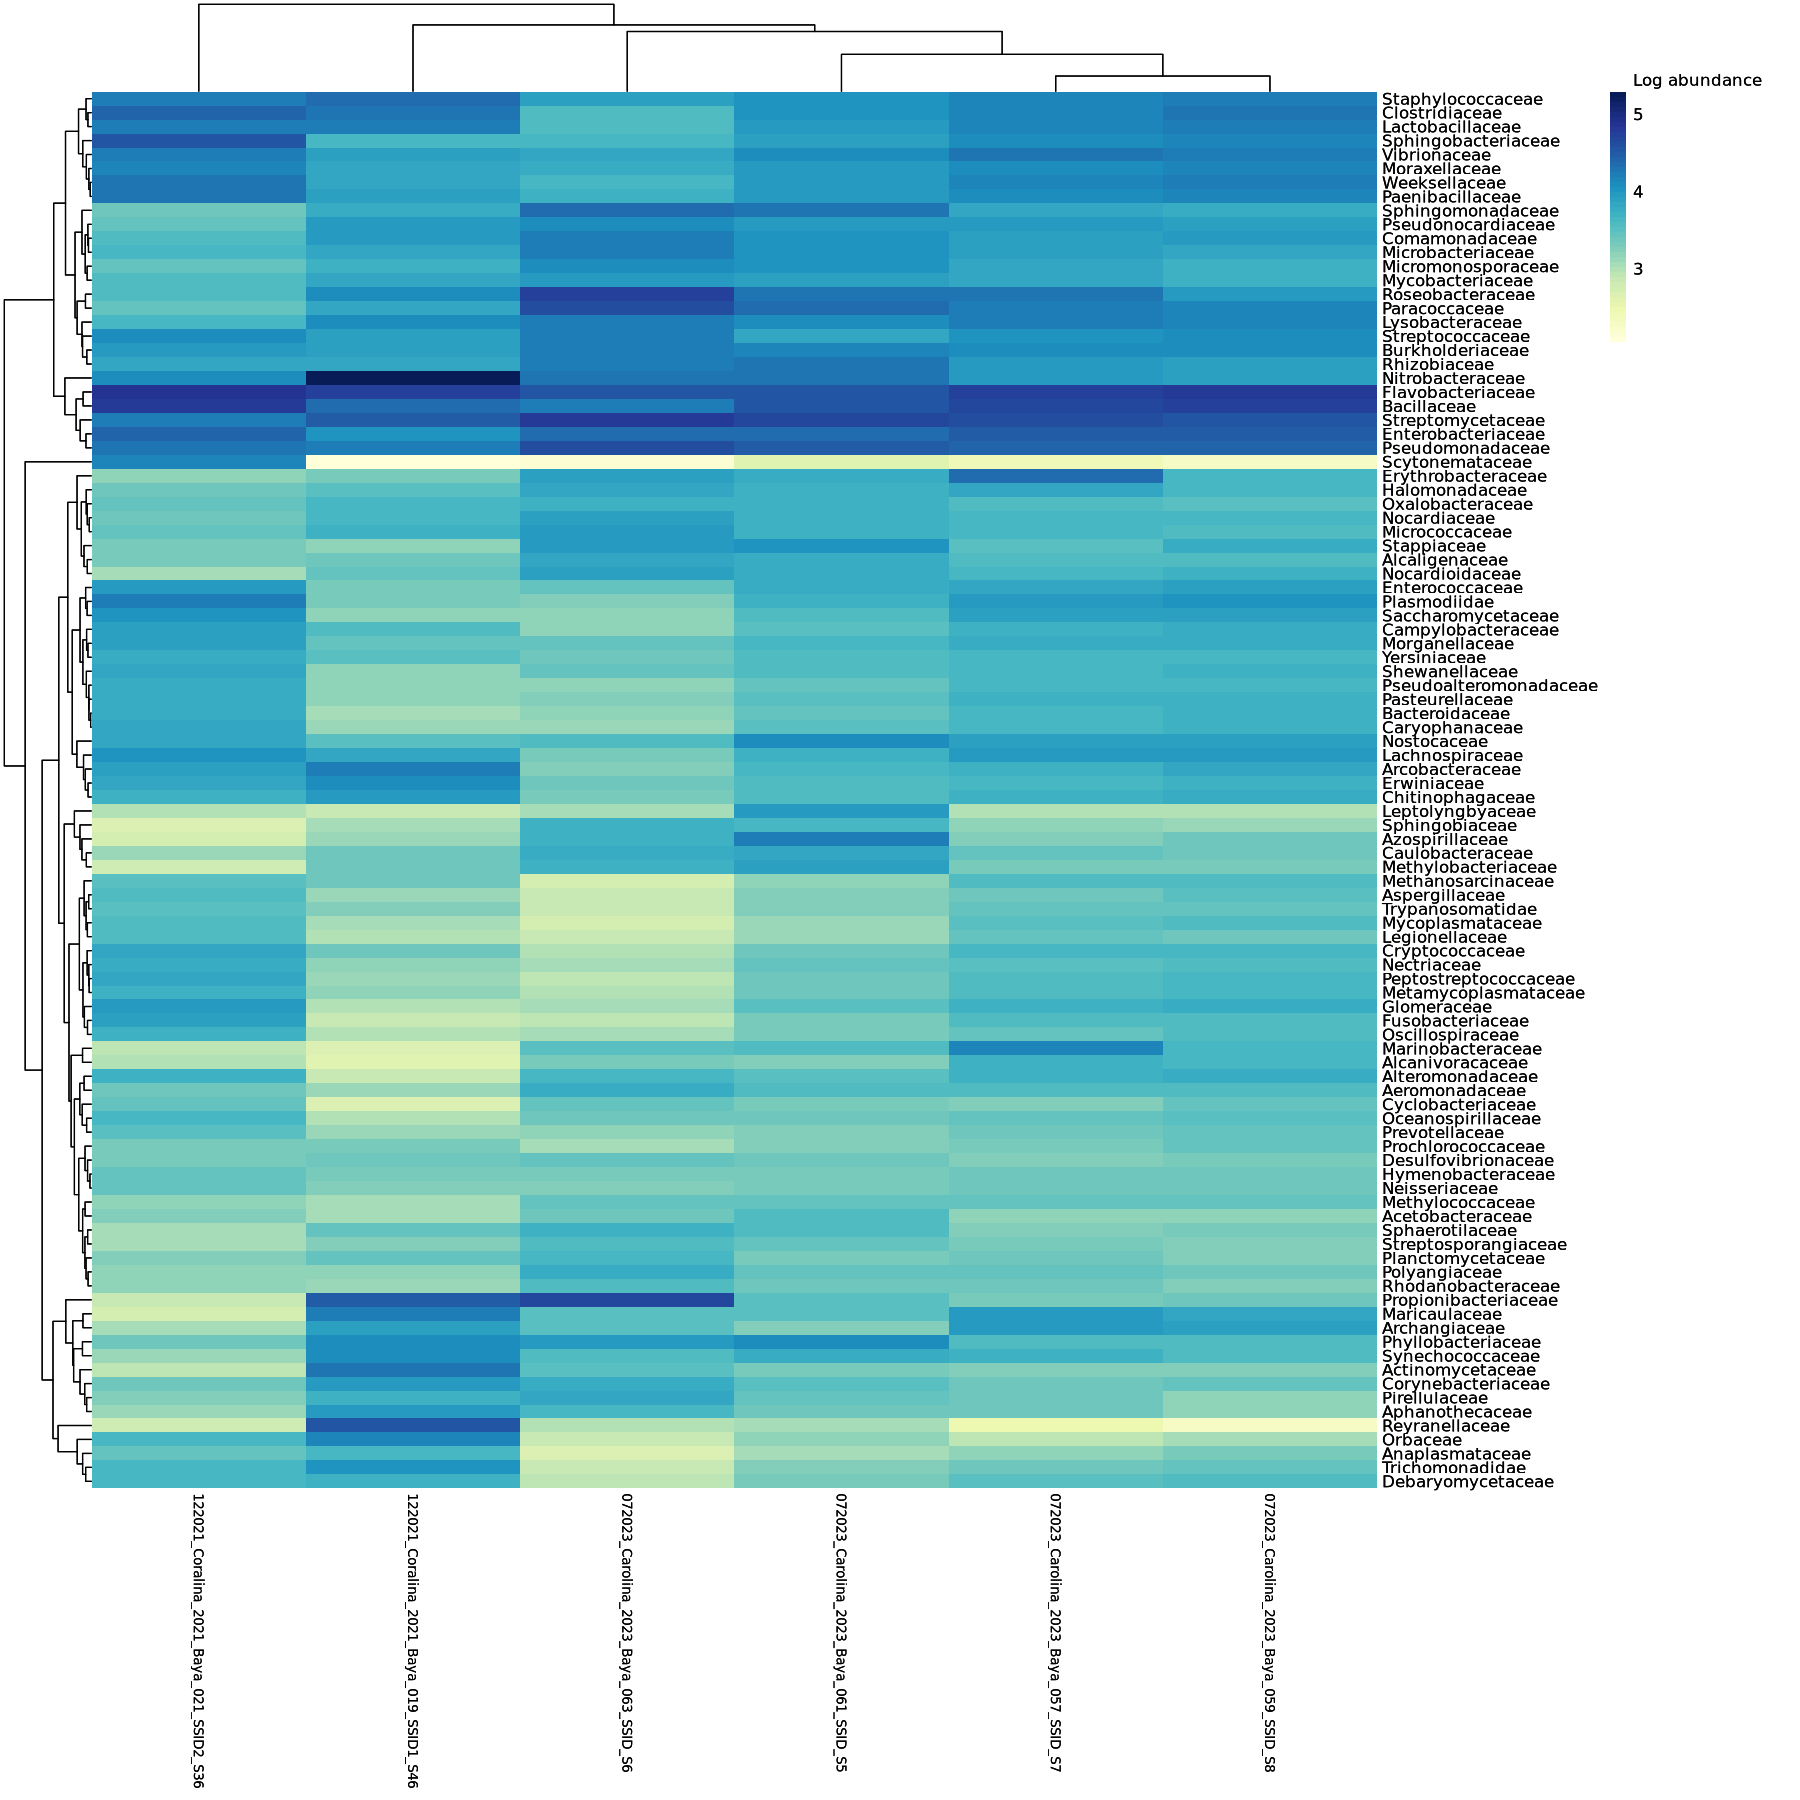

In [29]:
SSID_100_log_plot <- pheatmap(SSID_100_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 8,
         legend_breaks = c(1, 2, 3, 4, 5, max(SSID_100_log_counts)),
         legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
SSID_100_log_plot

In [45]:
ggsave(filename = "ssid_100_log_heatmap.png", plot = SSID_100_log_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

## MCAV

In [22]:
DR_mcav <- subset_samples(DR_f_all, Species == "MCAV")
DR_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 835 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 835 taxa by 1 taxonomic ranks ]

going straight to relative abundances here because I think that makes more sense to use

In [65]:
#now do relative abundance plot and then prune to top 50
DR_mcav_rel <- transform_sample_counts(DR_mcav, function(x) x / sum(x))
DR_mcav_rel_50 = prune_taxa(names(sort(taxa_sums(DR_mcav_rel),TRUE)[1:50]), DR_mcav_rel)

In [66]:
sample_data(DR_mcav_rel_50)$Type_m <- factor(sample_data(DR_mcav_rel_50)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

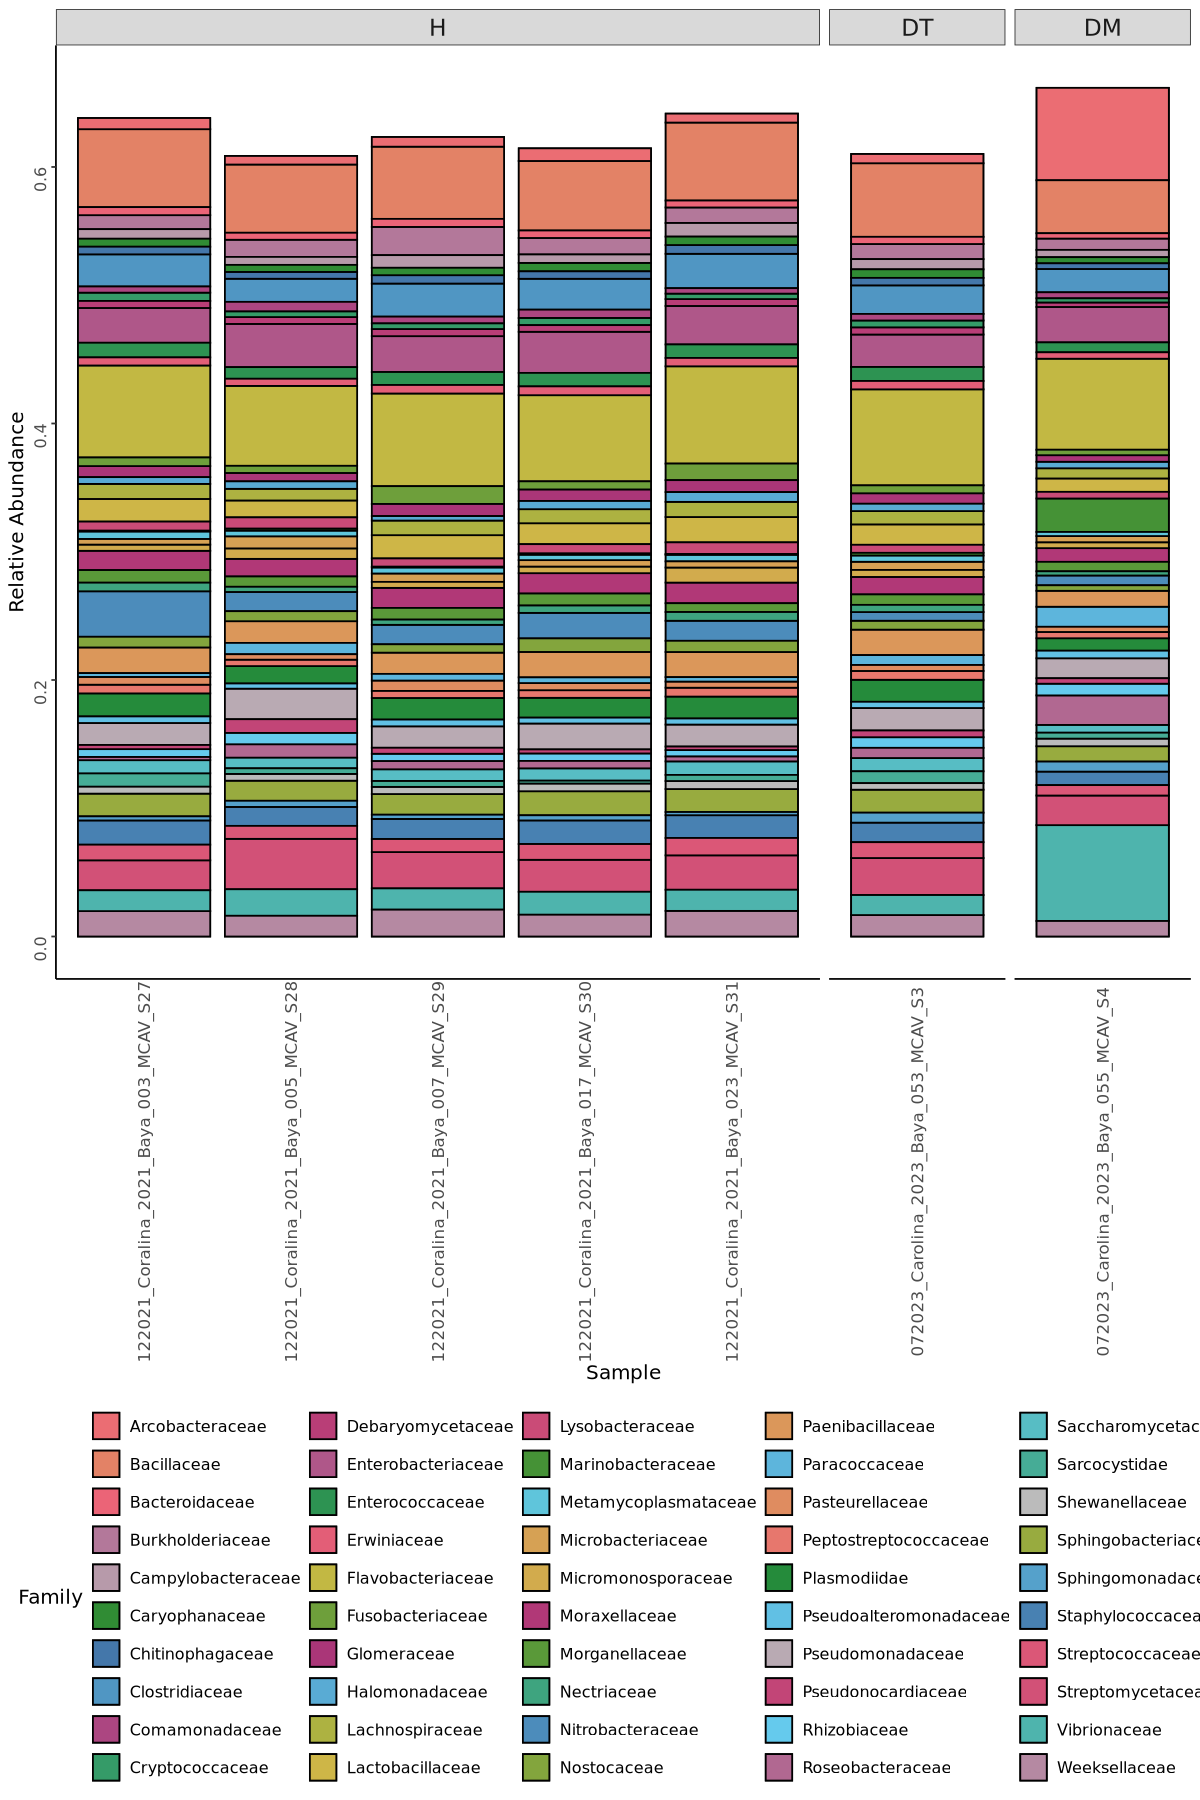

In [67]:
#taxa rel plot top 50 families
DR_mcav_50_rel_plot<-plot_bar(DR_mcav_rel_50,fill='species')+
facet_grid(~Type_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_mcav_50_rel_plot

In [72]:
ggsave(filename = "DR_mcav_rel_top_50_families_bar.png", plot = DR_mcav_50_rel_plot, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

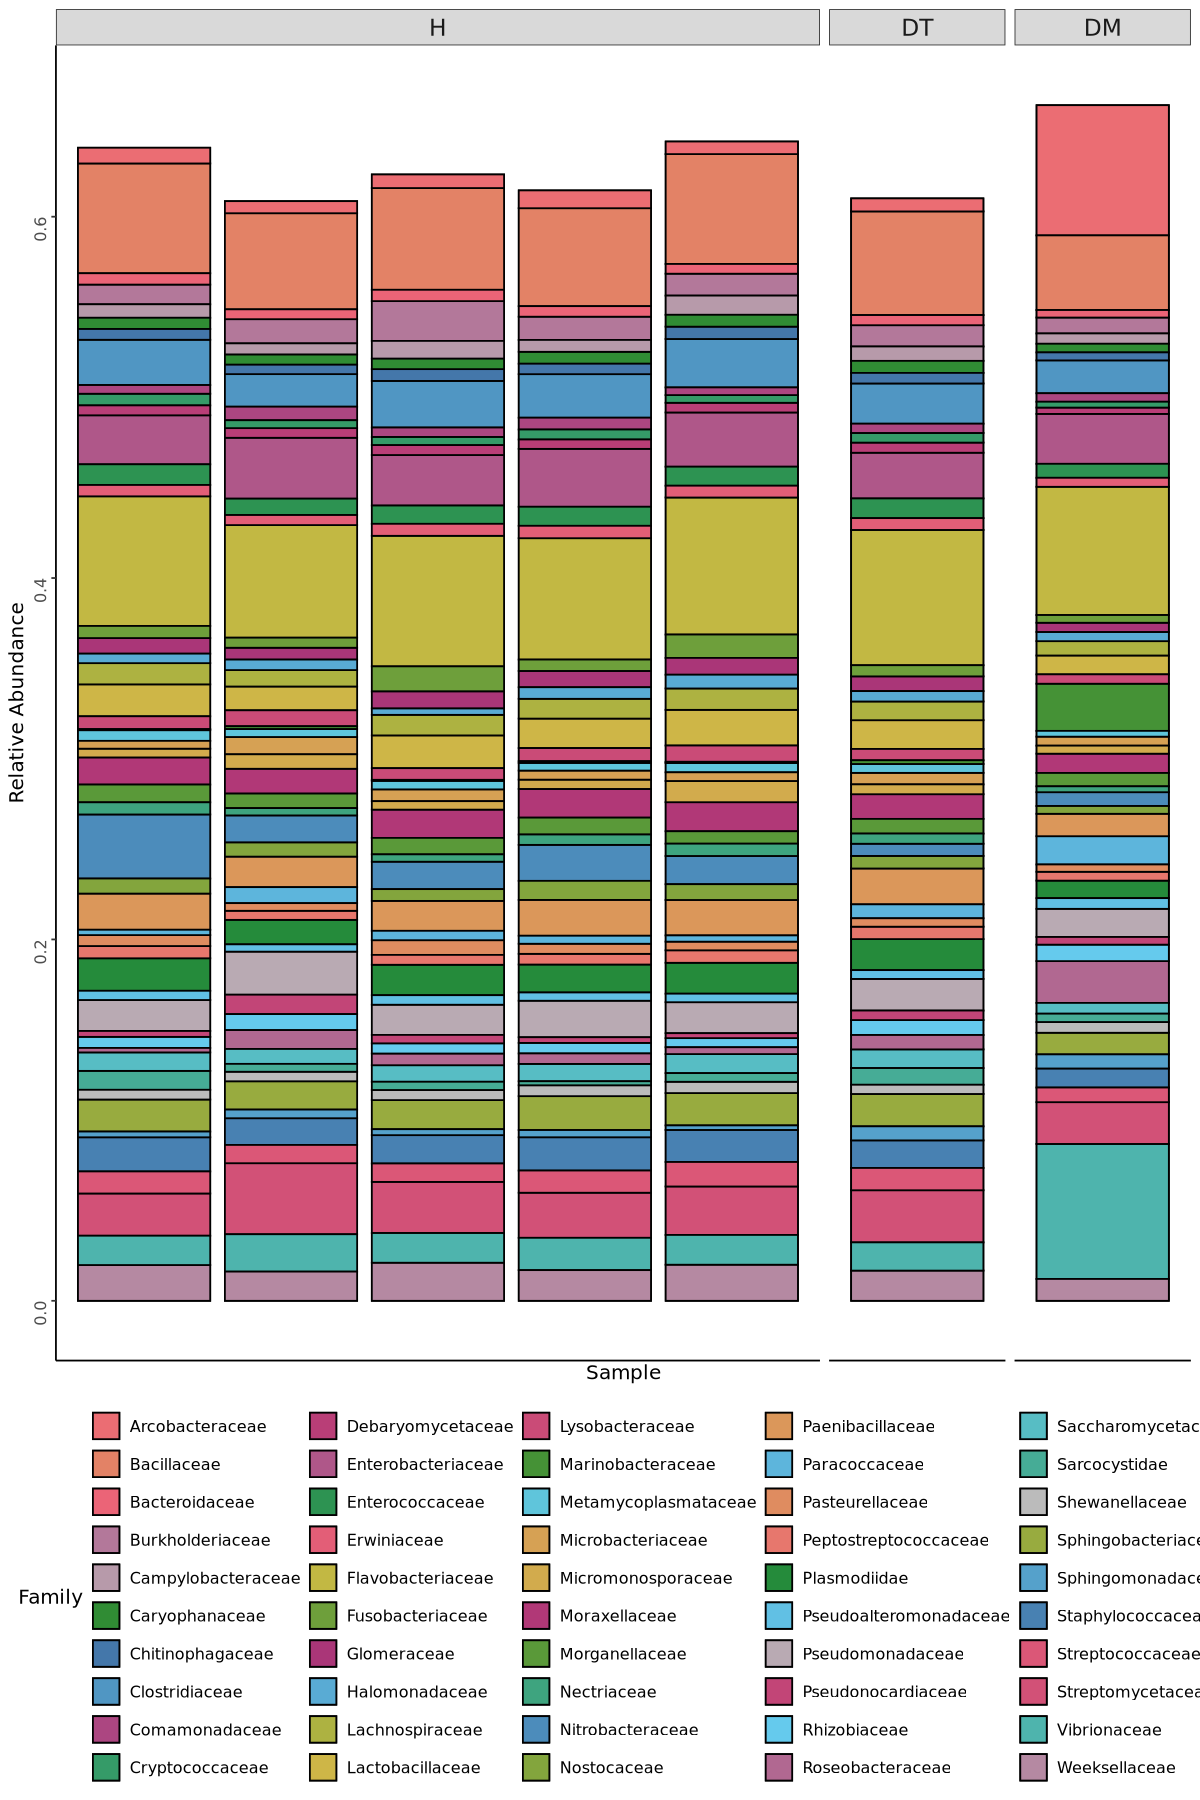

In [70]:
#taxa rel plot top 50 families
DR_mcav_50_rel_plot1<-plot_bar(DR_mcav_rel_50,fill='species')+
facet_grid(~Type_m, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          #axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.text.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_mcav_50_rel_plot1

In [71]:
ggsave(filename = "DR_mcav_rel_top_50_families_bar_nolabels.png", plot = DR_mcav_50_rel_plot1, 
      width = 10,
      height = 12,
      units = "in",
      dpi = 300)

### heatmap

In [31]:
#now prune to top 50 families
DR_mcav_50 = prune_taxa(names(sort(taxa_sums(DR_mcav),TRUE)[1:50]), DR_mcav)

In [32]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
mcav_50_otu_mat <- as(otu_table(DR_mcav_50), "matrix")
if (!taxa_are_rows(DR_mcav_50)) {
  mcav_50_otu_mat <- t(mcav_50_otu_mat)
}

In [33]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
mcav_50_tax_mat <- as(tax_table(DR_mcav_50), "matrix")
rownames(mcav_50_otu_mat) <- mcav_50_tax_mat[, "species"] 

In [34]:
#turn abundances into log values
mcav_50_log_counts <- log10(mcav_50_otu_mat + 1)

In [36]:
options(repr.plot.width=10, repr.plot.height=10)

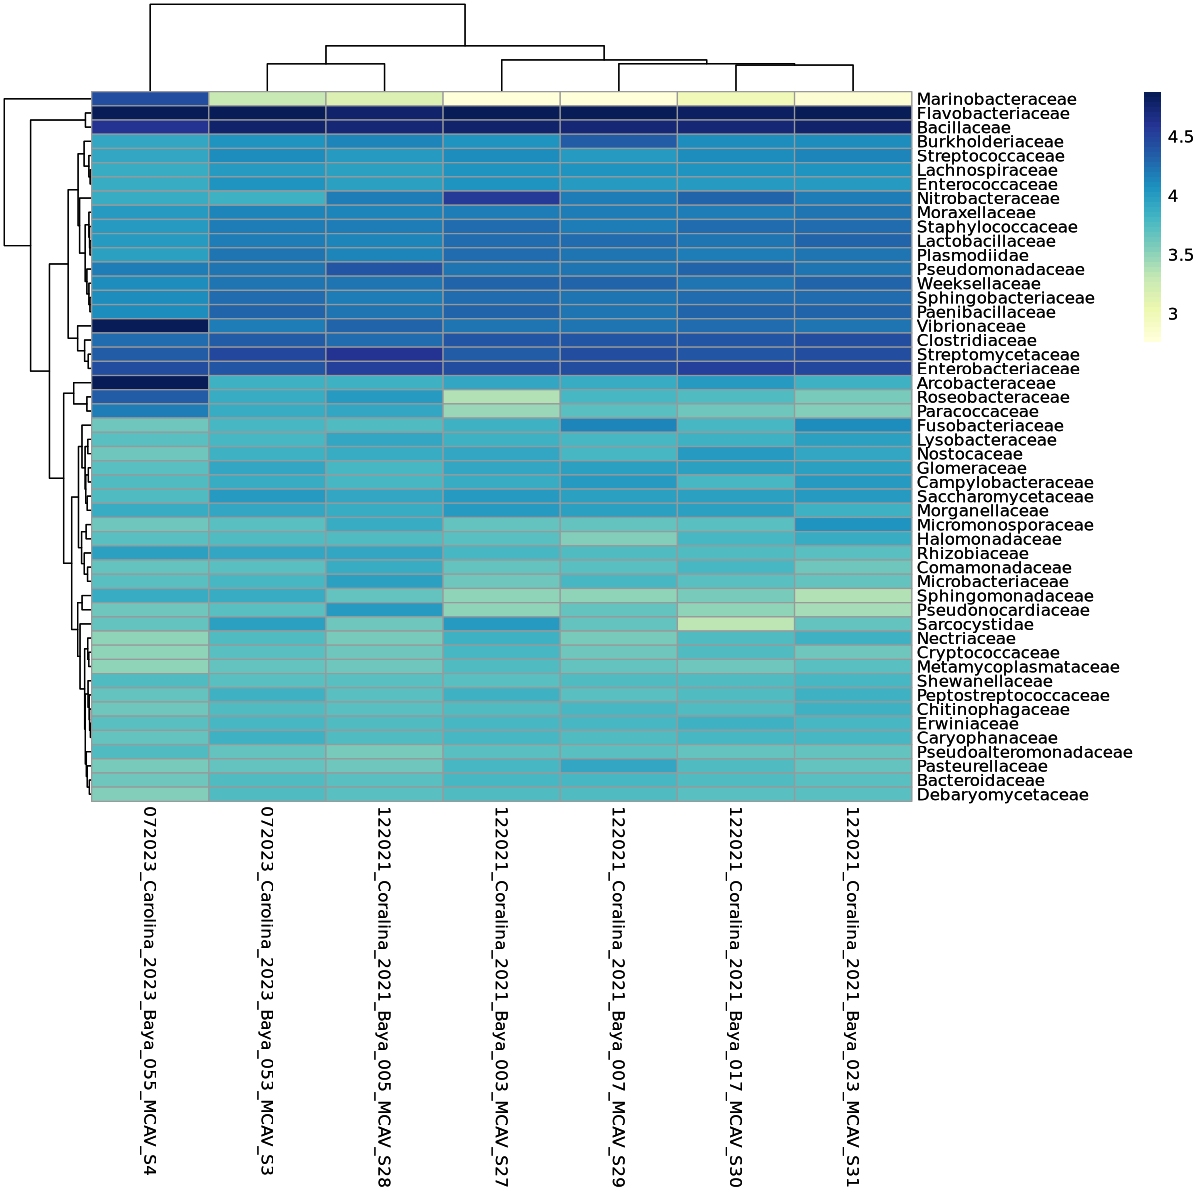

In [39]:
MCAV_50_log_plot <- pheatmap(mcav_50_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 10,
         #legend_breaks = c(1, 2, 3, 4, 5, max(mcav_50_log_counts)),
         #legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
MCAV_50_log_plot

In [40]:
ggsave(filename = "mcav_50_log_heatmap.png", plot = MCAV_50_log_plot, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [24]:
DR_mcav_noS27 <- subset_samples(DR_mcav, sample_names(DR_mcav) != "122021_Coralina_2021_Baya_003_MCAV_S27")

In [25]:
#now prune to top 100 families
DR_mcav_100 = prune_taxa(names(sort(taxa_sums(DR_mcav_noS27),TRUE)[1:100]), DR_mcav_noS27)

In [26]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
mcav_100_otu_mat <- as(otu_table(DR_mcav_100), "matrix")
if (!taxa_are_rows(DR_mcav_100)) {
  mcav_100_otu_mat <- t(mcav_100_otu_mat)
}

In [27]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
mcav_100_tax_mat <- as(tax_table(DR_mcav_100), "matrix")
rownames(mcav_100_otu_mat) <- mcav_100_tax_mat[, "species"]

In [28]:
#turn abundances into log values
mcav_100_log_counts <- log10(mcav_100_otu_mat)

In [29]:
options(repr.plot.width=15, repr.plot.height=15)

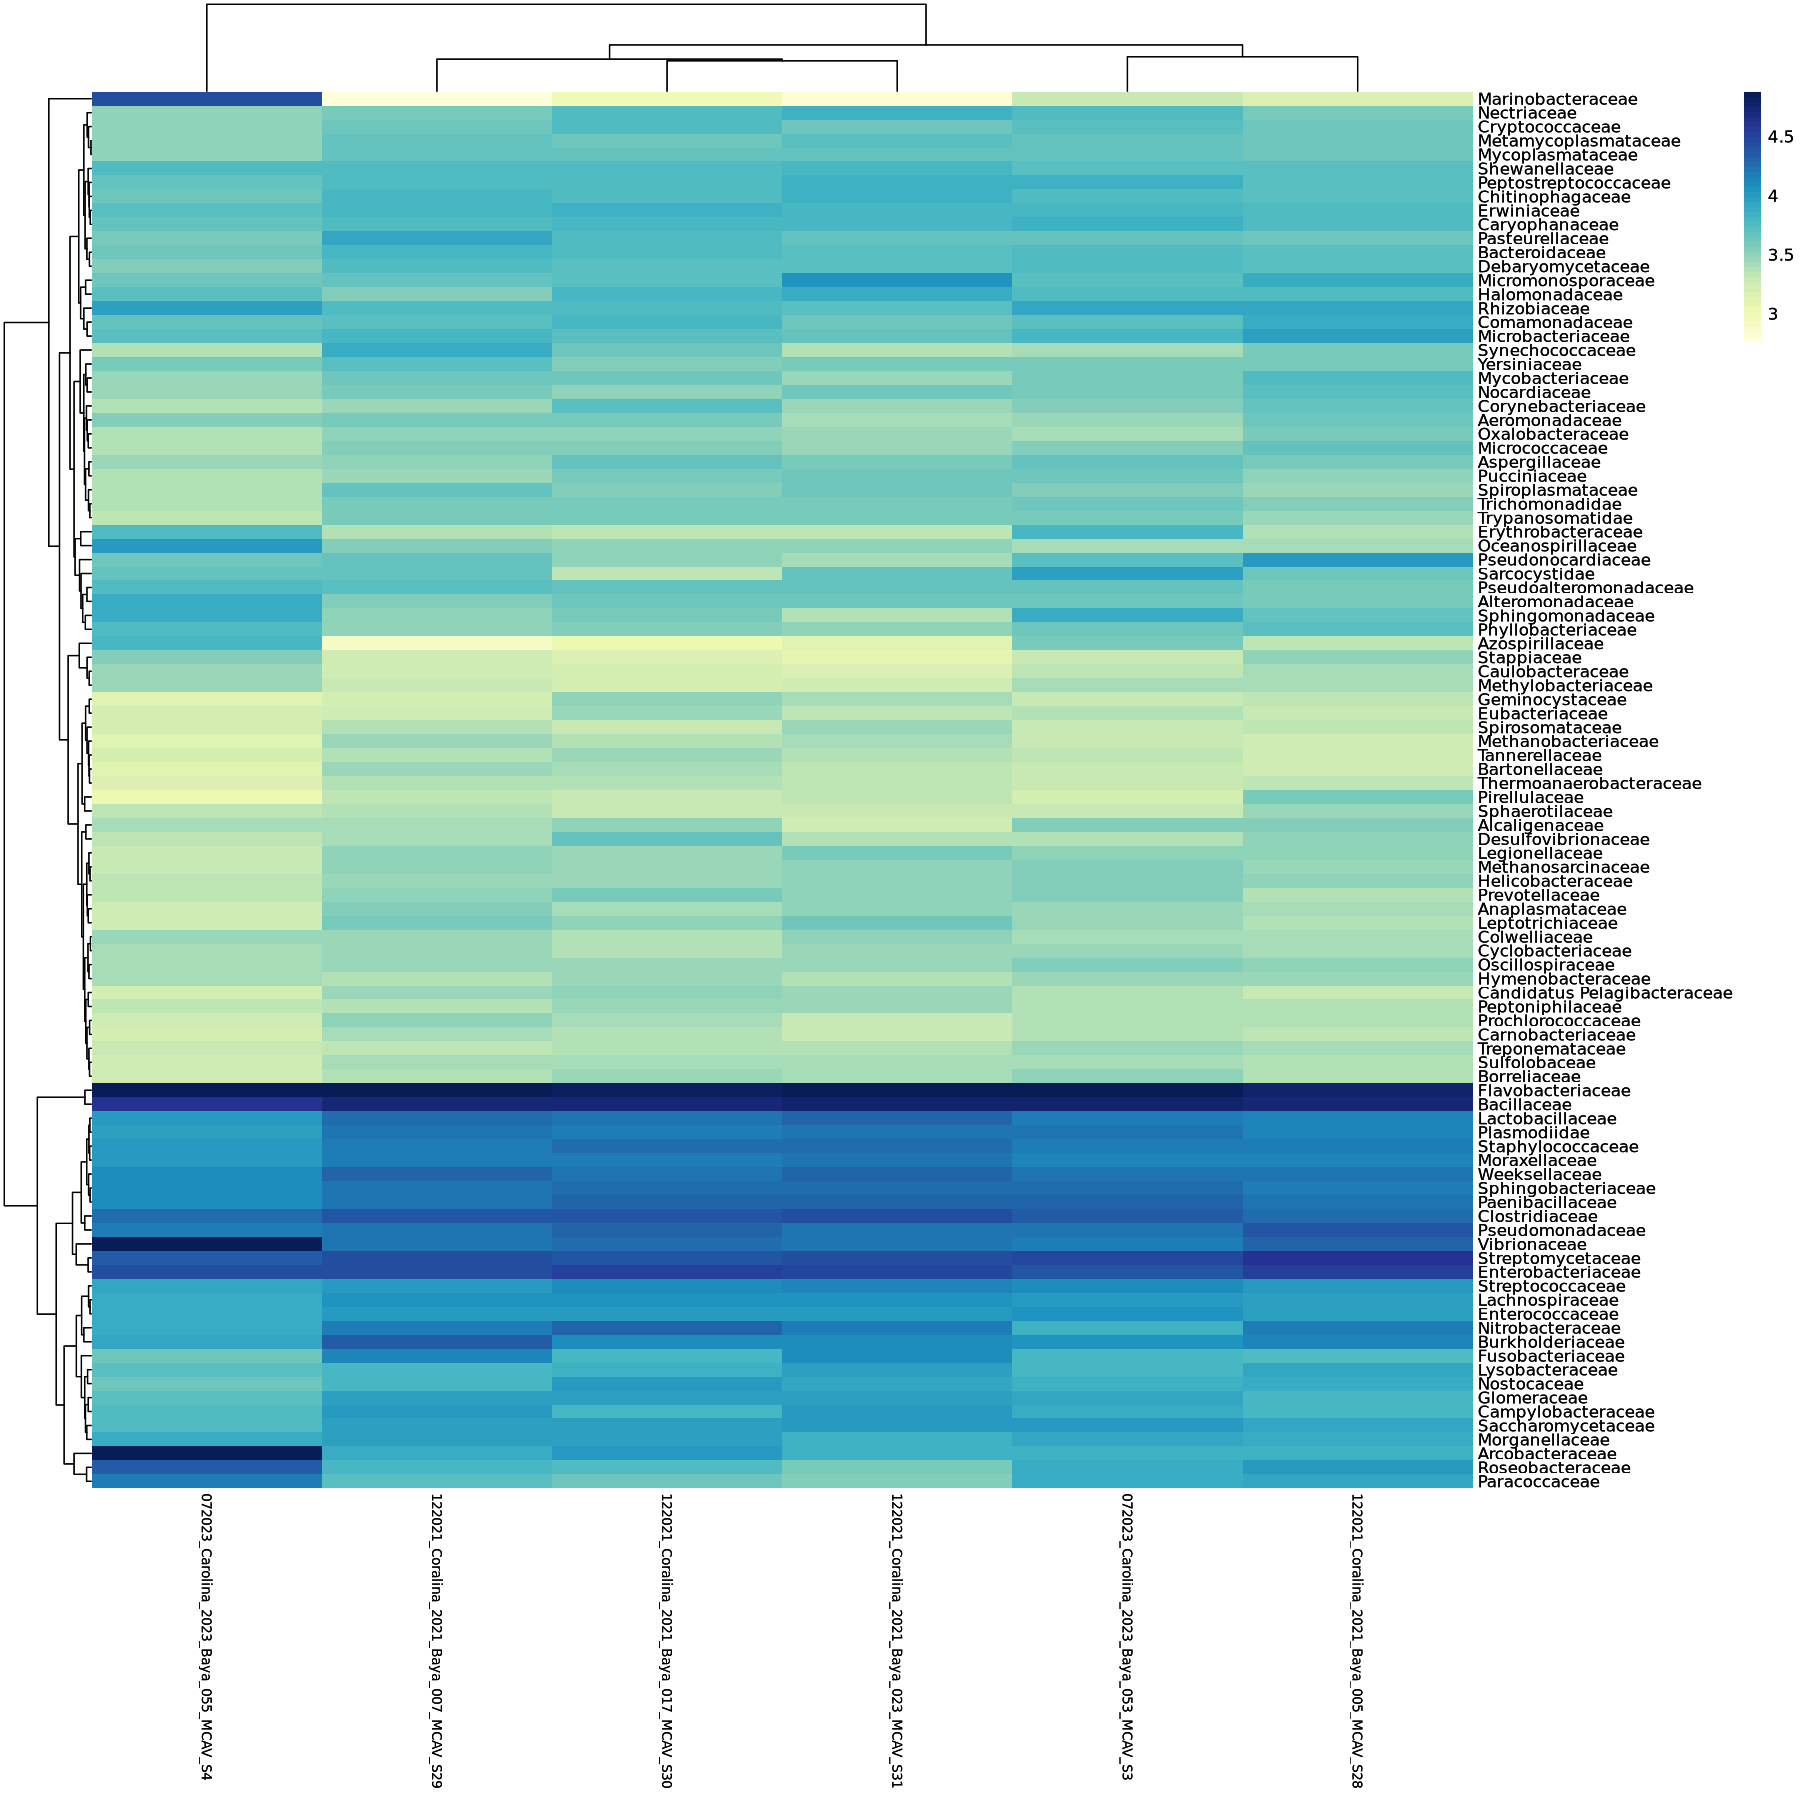

In [30]:
MCAV_100_log_plot <- pheatmap(mcav_100_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 8,
         #legend_breaks = c(1, 2, 3, 4, 5, max(mcav_100_log_counts)),
         #legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
MCAV_100_log_plot

In [31]:
ggsave(filename = "mcav_100_log_heatmap_noS27.png", plot = MCAV_100_log_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

## DCYL

In [20]:
DR_dcyl <- subset_samples(DR_f_all, Species == "DCYL")
DR_dcyl

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 835 taxa and 6 samples ]
sample_data() Sample Data:       [ 6 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 835 taxa by 1 taxonomic ranks ]

In [91]:
#now do relative abundance plot and then prune to top 50
DR_dcyl_rel <- transform_sample_counts(DR_dcyl, function(x) x / sum(x))
DR_dcyl_rel_50 = prune_taxa(names(sort(taxa_sums(DR_dcyl_rel),TRUE)[1:50]), DR_dcyl_rel)

In [75]:
sample_data(DR_dcyl_rel_50)$Type_d <- factor(sample_data(DR_dcyl_rel_50)$Sample_type, 
                                      levels = c("H", "DT", "DM"))

In [79]:
options(repr.plot.width=10, repr.plot.height=15)

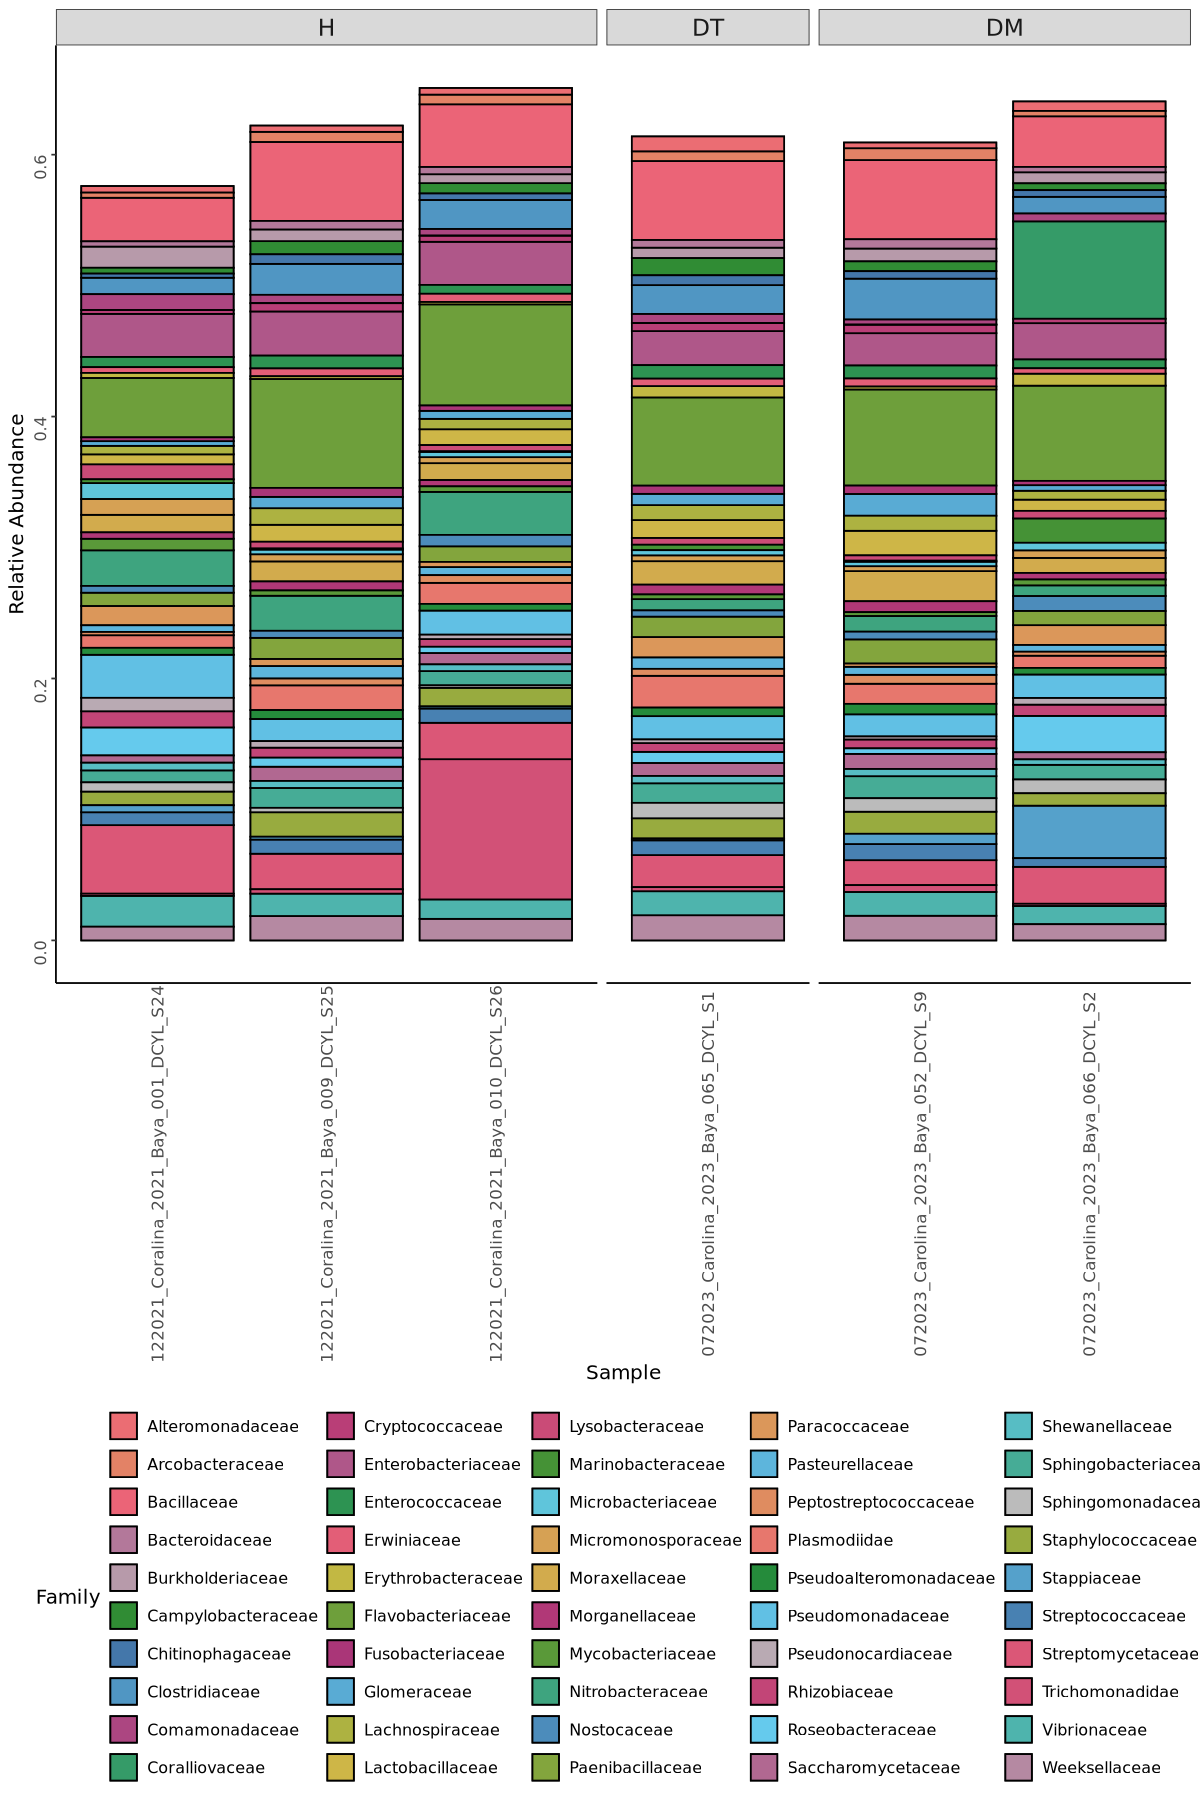

In [80]:
#taxa rel plot top 50 families
DR_dcyl_50_rel_plot<-plot_bar(DR_dcyl_rel_50,fill='species')+
facet_grid(~Type_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_dcyl_50_rel_plot

In [81]:
ggsave(filename = "DR_dcyl_rel_top_50_families_bar.png", plot = DR_dcyl_50_rel_plot, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

In [82]:
options(repr.plot.width=10, repr.plot.height=12)

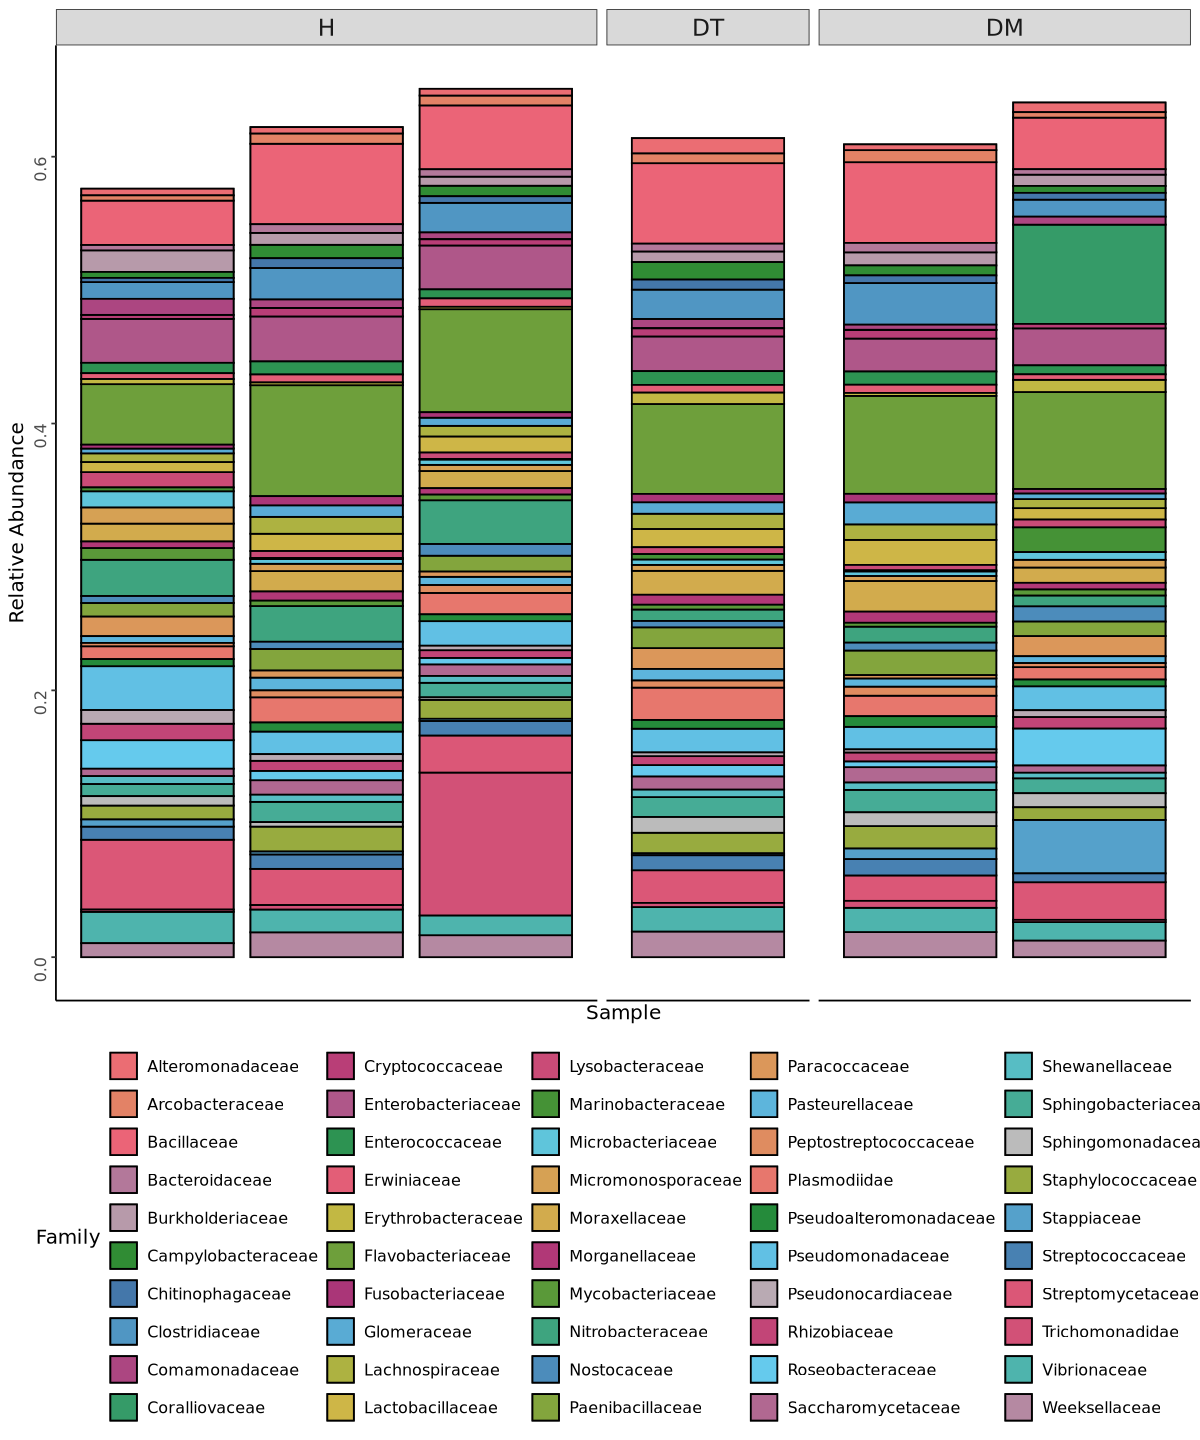

In [83]:
#taxa rel plot top 50 families
DR_dcyl_50_rel_plot1<-plot_bar(DR_dcyl_rel_50,fill='species')+
facet_grid(~Type_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          #axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.text.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_dcyl_50_rel_plot1

In [84]:
ggsave(filename = "DR_dcyl_rel_top_50_families_bar_nolabels.png", plot = DR_dcyl_50_rel_plot1, 
      width = 10,
      height = 12,
      units = "in",
      dpi = 300)

In [92]:
#facet by colony
sample_data(DR_dcyl_rel_50)$Tag_d <- factor(sample_data(DR_dcyl_rel_50)$Tag, 
                                      levels = c("DCYL-6", "DCYL-5", "DCYL-1"))

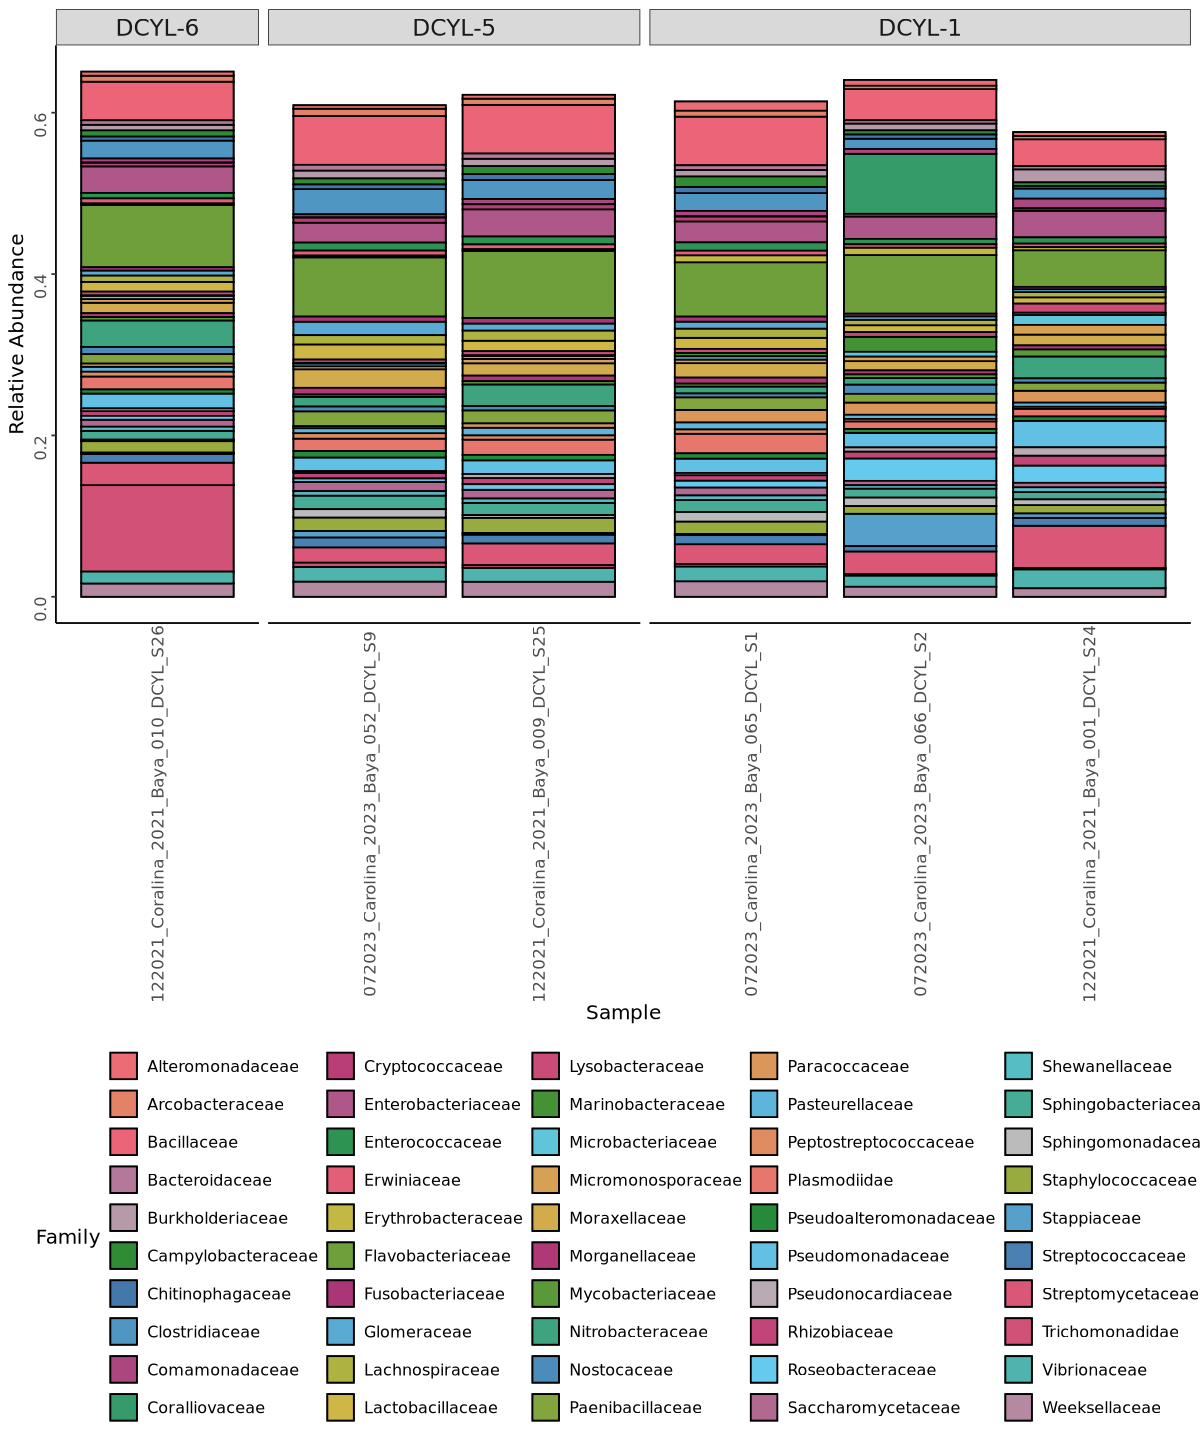

In [93]:
#taxa rel plot top 50 families
DR_dcyl_50_rel_plot2<-plot_bar(DR_dcyl_rel_50,fill='species')+
facet_grid(~Tag_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_dcyl_50_rel_plot2

In [87]:
ggsave(filename = "DR_dcyl_rel_top_50_families_bar_colony.png", plot = DR_dcyl_50_rel_plot2, 
      width = 10,
      height = 15,
      units = "in",
      dpi = 300)

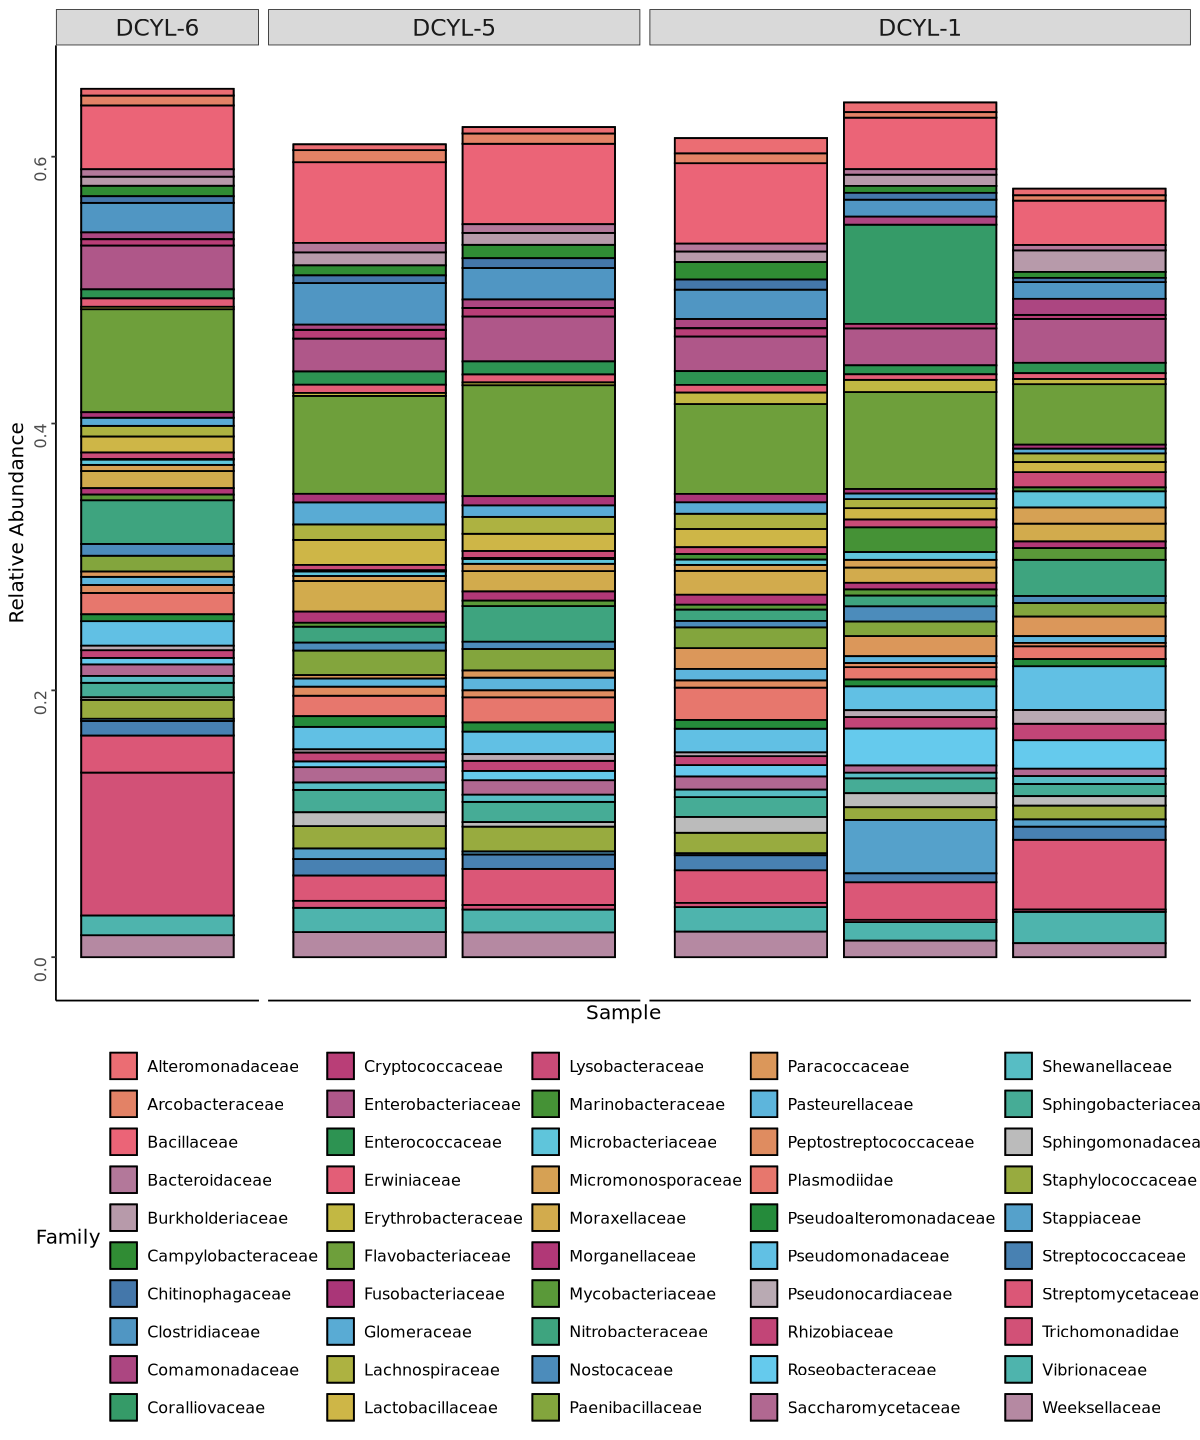

In [94]:
#no labels
DR_dcyl_50_rel_plot3<-plot_bar(DR_dcyl_rel_50,fill='species')+
facet_grid(~Tag_d, scales="free_x", space="free")+
geom_bar(aes(fill=species), stat="identity", position="stack", color="black")+
scale_fill_manual(values = shuffled_colors) +
theme_bw()+
theme(legend.position="bottom", panel.border = element_blank(), 
          panel.grid.major.x = element_blank(), 
          panel.grid.minor.x = element_blank(),
          panel.grid.major.y = element_blank(), 
          panel.grid.minor.y = element_blank(),
          strip.text = element_text(size = 14), 
          #axis.text.x = element_text(hjust = 0.5, vjust = 0.5, size = 10),  # Adjust text size
          axis.text.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
          text = element_text(size=12))+
labs(x = "Sample", y = "Relative Abundance", fill = "Family")
DR_dcyl_50_rel_plot3

In [95]:
ggsave(filename = "DR_dcyl_rel_top_50_families_bar_colony_nolabels.png", plot = DR_dcyl_50_rel_plot3, 
      width = 10,
      height = 12,
      units = "in",
      dpi = 300)

### heatmap

In [57]:
#now prune to top 50 families
DR_dcyl_50 = prune_taxa(names(sort(taxa_sums(DR_dcyl),TRUE)[1:50]), DR_dcyl)

In [58]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
dcyl_50_otu_mat <- as(otu_table(DR_dcyl_50), "matrix")
if (!taxa_are_rows(DR_dcyl_50)) {
  dcyl_50_otu_mat <- t(dcyl_50_otu_mat)
}

In [68]:
head(dcyl_50_otu_mat)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,122021_Coralina_2021_Baya_009_DCYL_S25,122021_Coralina_2021_Baya_010_DCYL_S26
Flavobacteriaceae,73419.08,67396.061,72716.408,45372.42,83172.56,77234.14
Bacillaceae,60501.36,60336.289,38675.848,33286.80,60331.07,47894.92
Nitrobacteraceae,12009.26,8614.534,8086.181,27182.39,26771.47,32838.13
Streptomycetaceae,19057.07,24484.625,28193.961,52352.80,27152.55,27790.52
Enterobacteriaceae,24700.28,26004.837,27736.354,32930.94,33726.33,32924.17
Clostridiaceae,31232.28,22066.106,12764.537,12564.67,23651.30,22198.00


In [59]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
dcyl_50_tax_mat <- as(tax_table(DR_dcyl_50), "matrix")
rownames(dcyl_50_otu_mat) <- dcyl_50_tax_mat[, "species"] 

In [69]:
#turn abundances into log values
dcyl_50_log_counts <- log10(dcyl_50_otu_mat+1)

In [61]:
options(repr.plot.width=10, repr.plot.height=10)

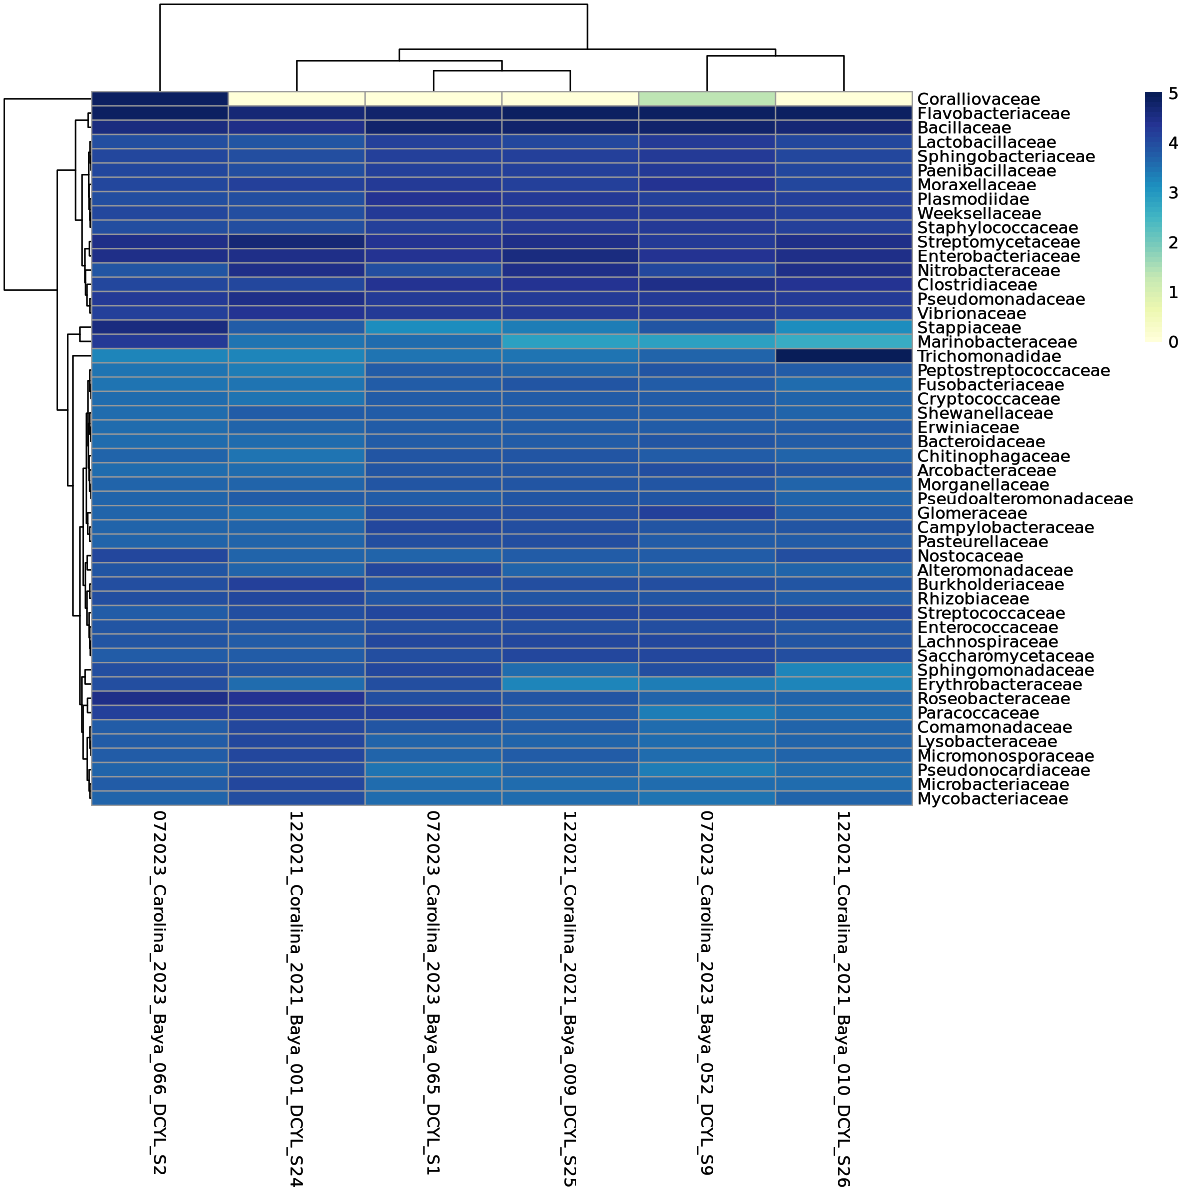

In [70]:
DCYL_50_log_plot <- pheatmap(dcyl_50_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 10,
         #legend_breaks = c(1, 2, 3, 4, 5, max(mcav_50_log_counts)),
         #legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
DCYL_50_log_plot

In [71]:
#top 100
DR_dcyl_100 = prune_taxa(names(sort(taxa_sums(DR_dcyl),TRUE)[1:100]), DR_dcyl)

In [72]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
dcyl_100_otu_mat <- as(otu_table(DR_dcyl_100), "matrix")
if (!taxa_are_rows(DR_dcyl_100)) {
  dcyl_100_otu_mat <- t(dcyl_100_otu_mat)
}

In [73]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
dcyl_100_tax_mat <- as(tax_table(DR_dcyl_100), "matrix")
rownames(dcyl_100_otu_mat) <- dcyl_100_tax_mat[, "species"] 

In [74]:
#turn abundances into log values
dcyl_100_log_counts <- log10(dcyl_100_otu_mat+1)

In [75]:
options(repr.plot.width=15, repr.plot.height=15)

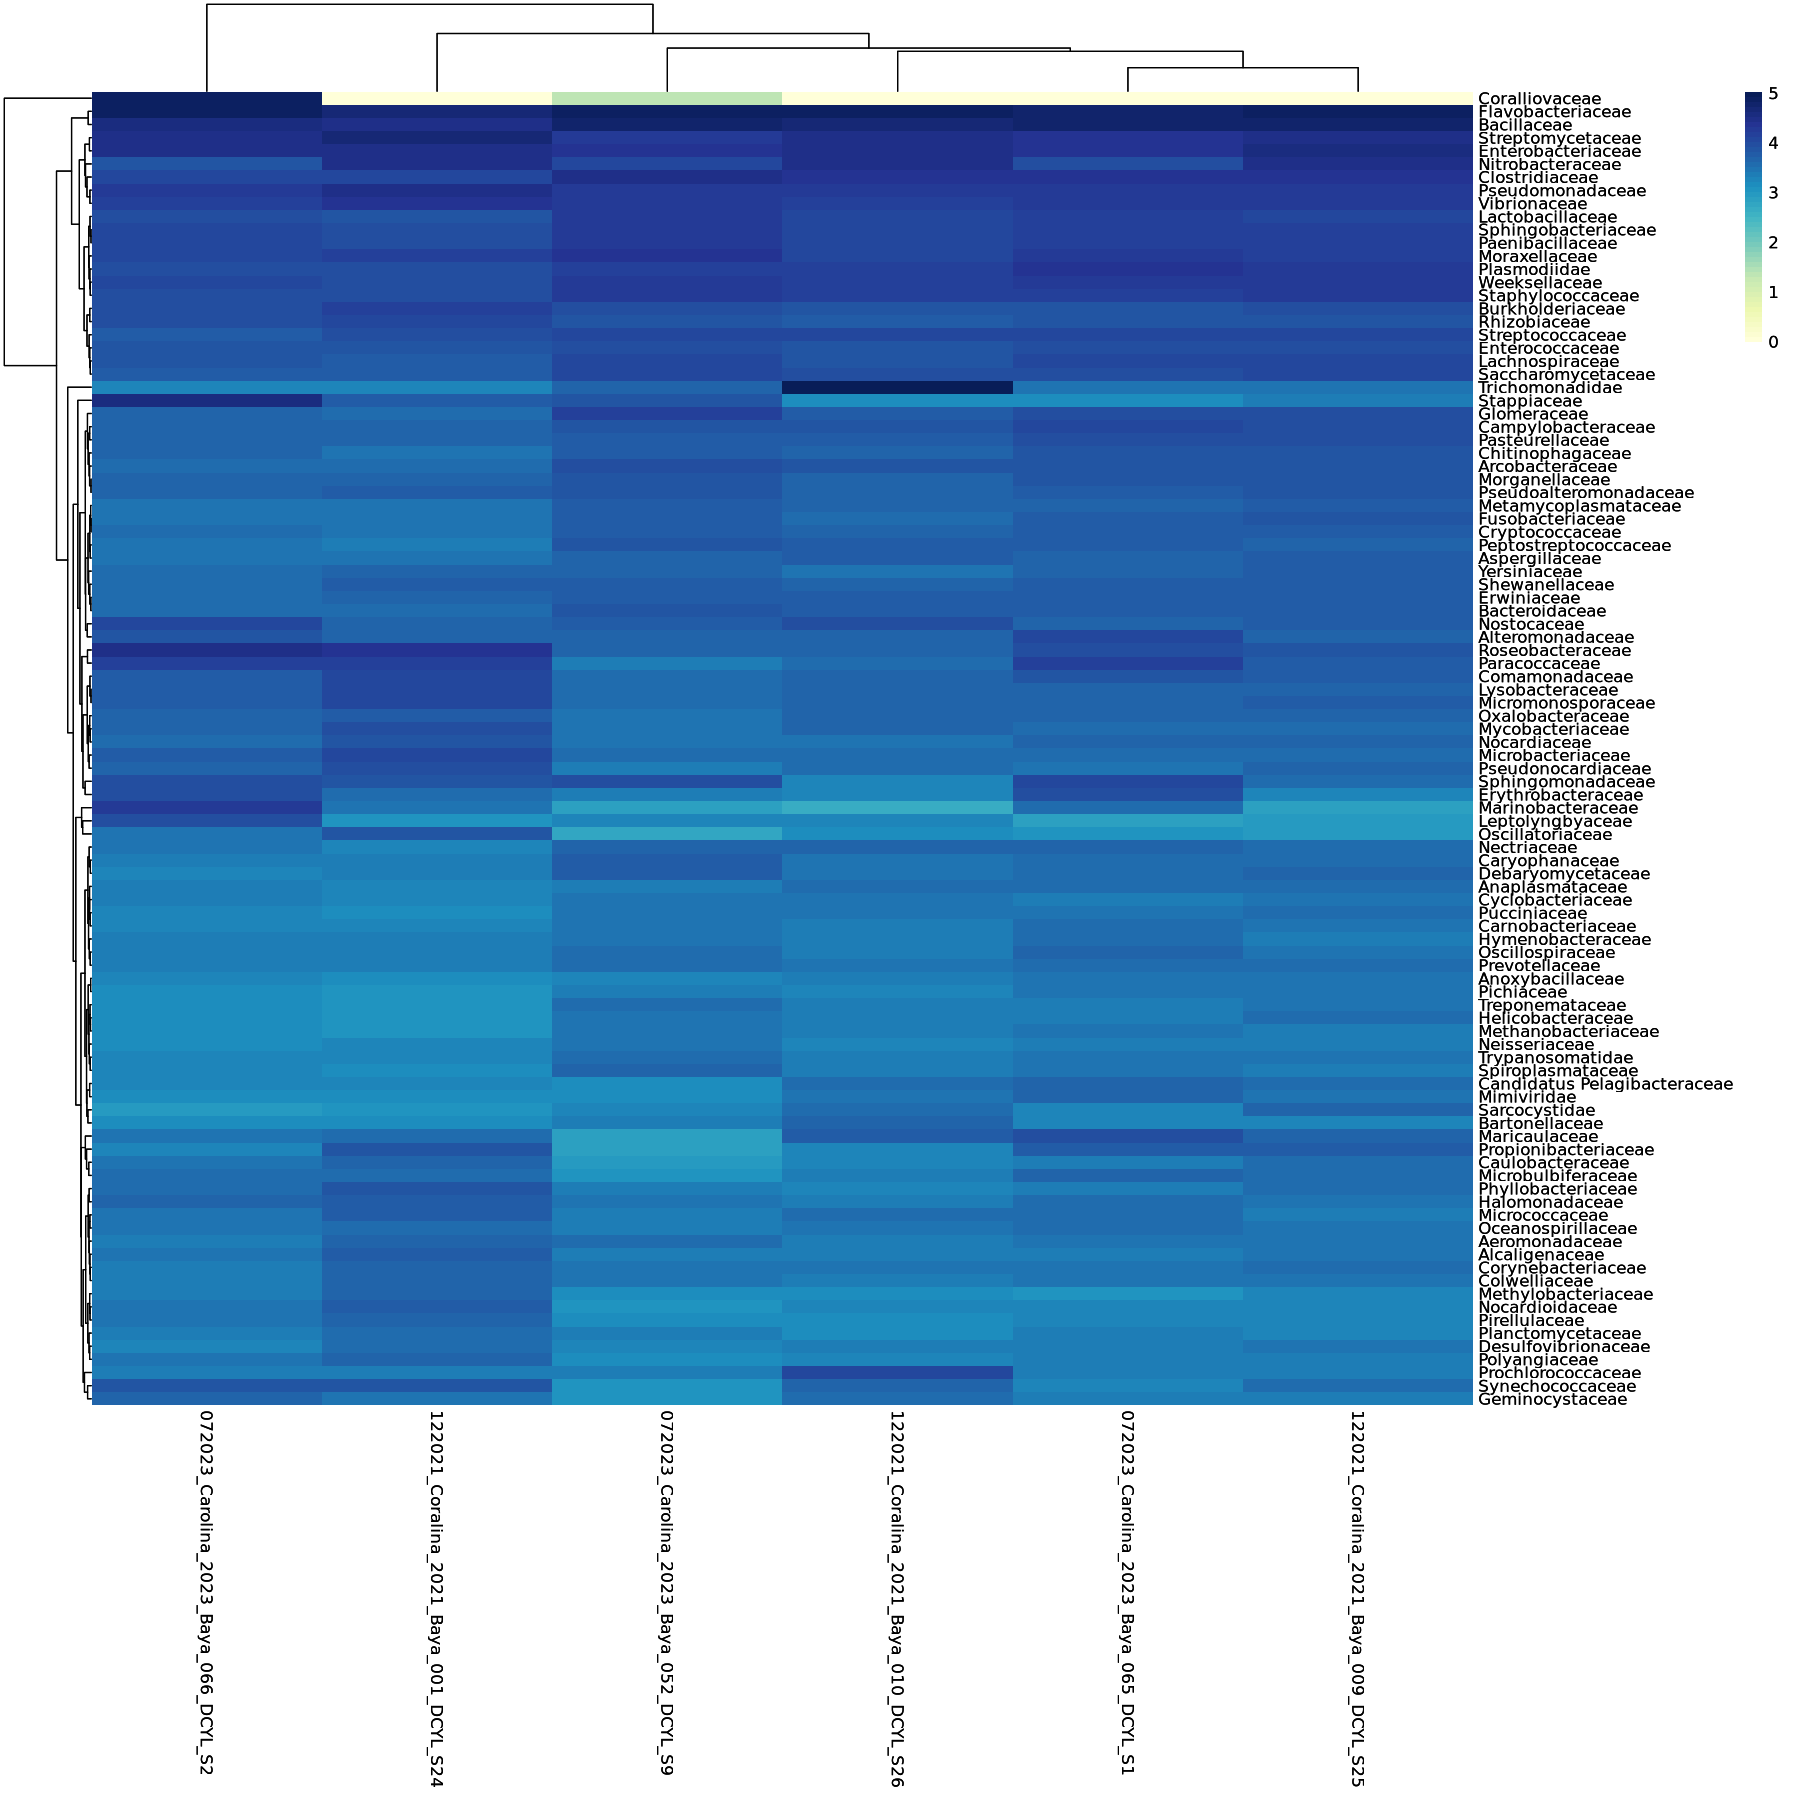

In [76]:
DCYL_100_log_plot <- pheatmap(dcyl_100_log_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 10,
         #legend_breaks = c(1, 2, 3, 4, 5, max(mcav_50_log_counts)),
         #legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
DCYL_100_log_plot

In [23]:
#weird, maybe remove coralliovaceae and see if that evens things out a bit
DR_dcyl_clean <- subset_taxa(DR_dcyl, species != "Coralliovaceae")

In [24]:
#top 100
DR_dcyl_100_clean = prune_taxa(names(sort(taxa_sums(DR_dcyl_clean),TRUE)[1:100]), DR_dcyl_clean)

In [25]:
#Extract the OTU table as a numeric matrix
#Ensure the orientation has taxa as rows and samples as columns
dcyl_100_cotu_mat <- as(otu_table(DR_dcyl_100_clean), "matrix")
if (!taxa_are_rows(DR_dcyl_100_clean)) {
  dcyl_100_cotu_mat <- t(dcyl_100_cotu_mat)
}

In [26]:
#Replace OTU IDs with actual taxonomic names (e.g., Family)
dcyl_100_ctax_mat <- as(tax_table(DR_dcyl_100_clean), "matrix")
rownames(dcyl_100_cotu_mat) <- dcyl_100_ctax_mat[, "species"]

In [27]:
#turn abundances into log values
dcyl_100_clog_counts <- log10(dcyl_100_cotu_mat+1)

In [28]:
options(repr.plot.width=15, repr.plot.height=15)

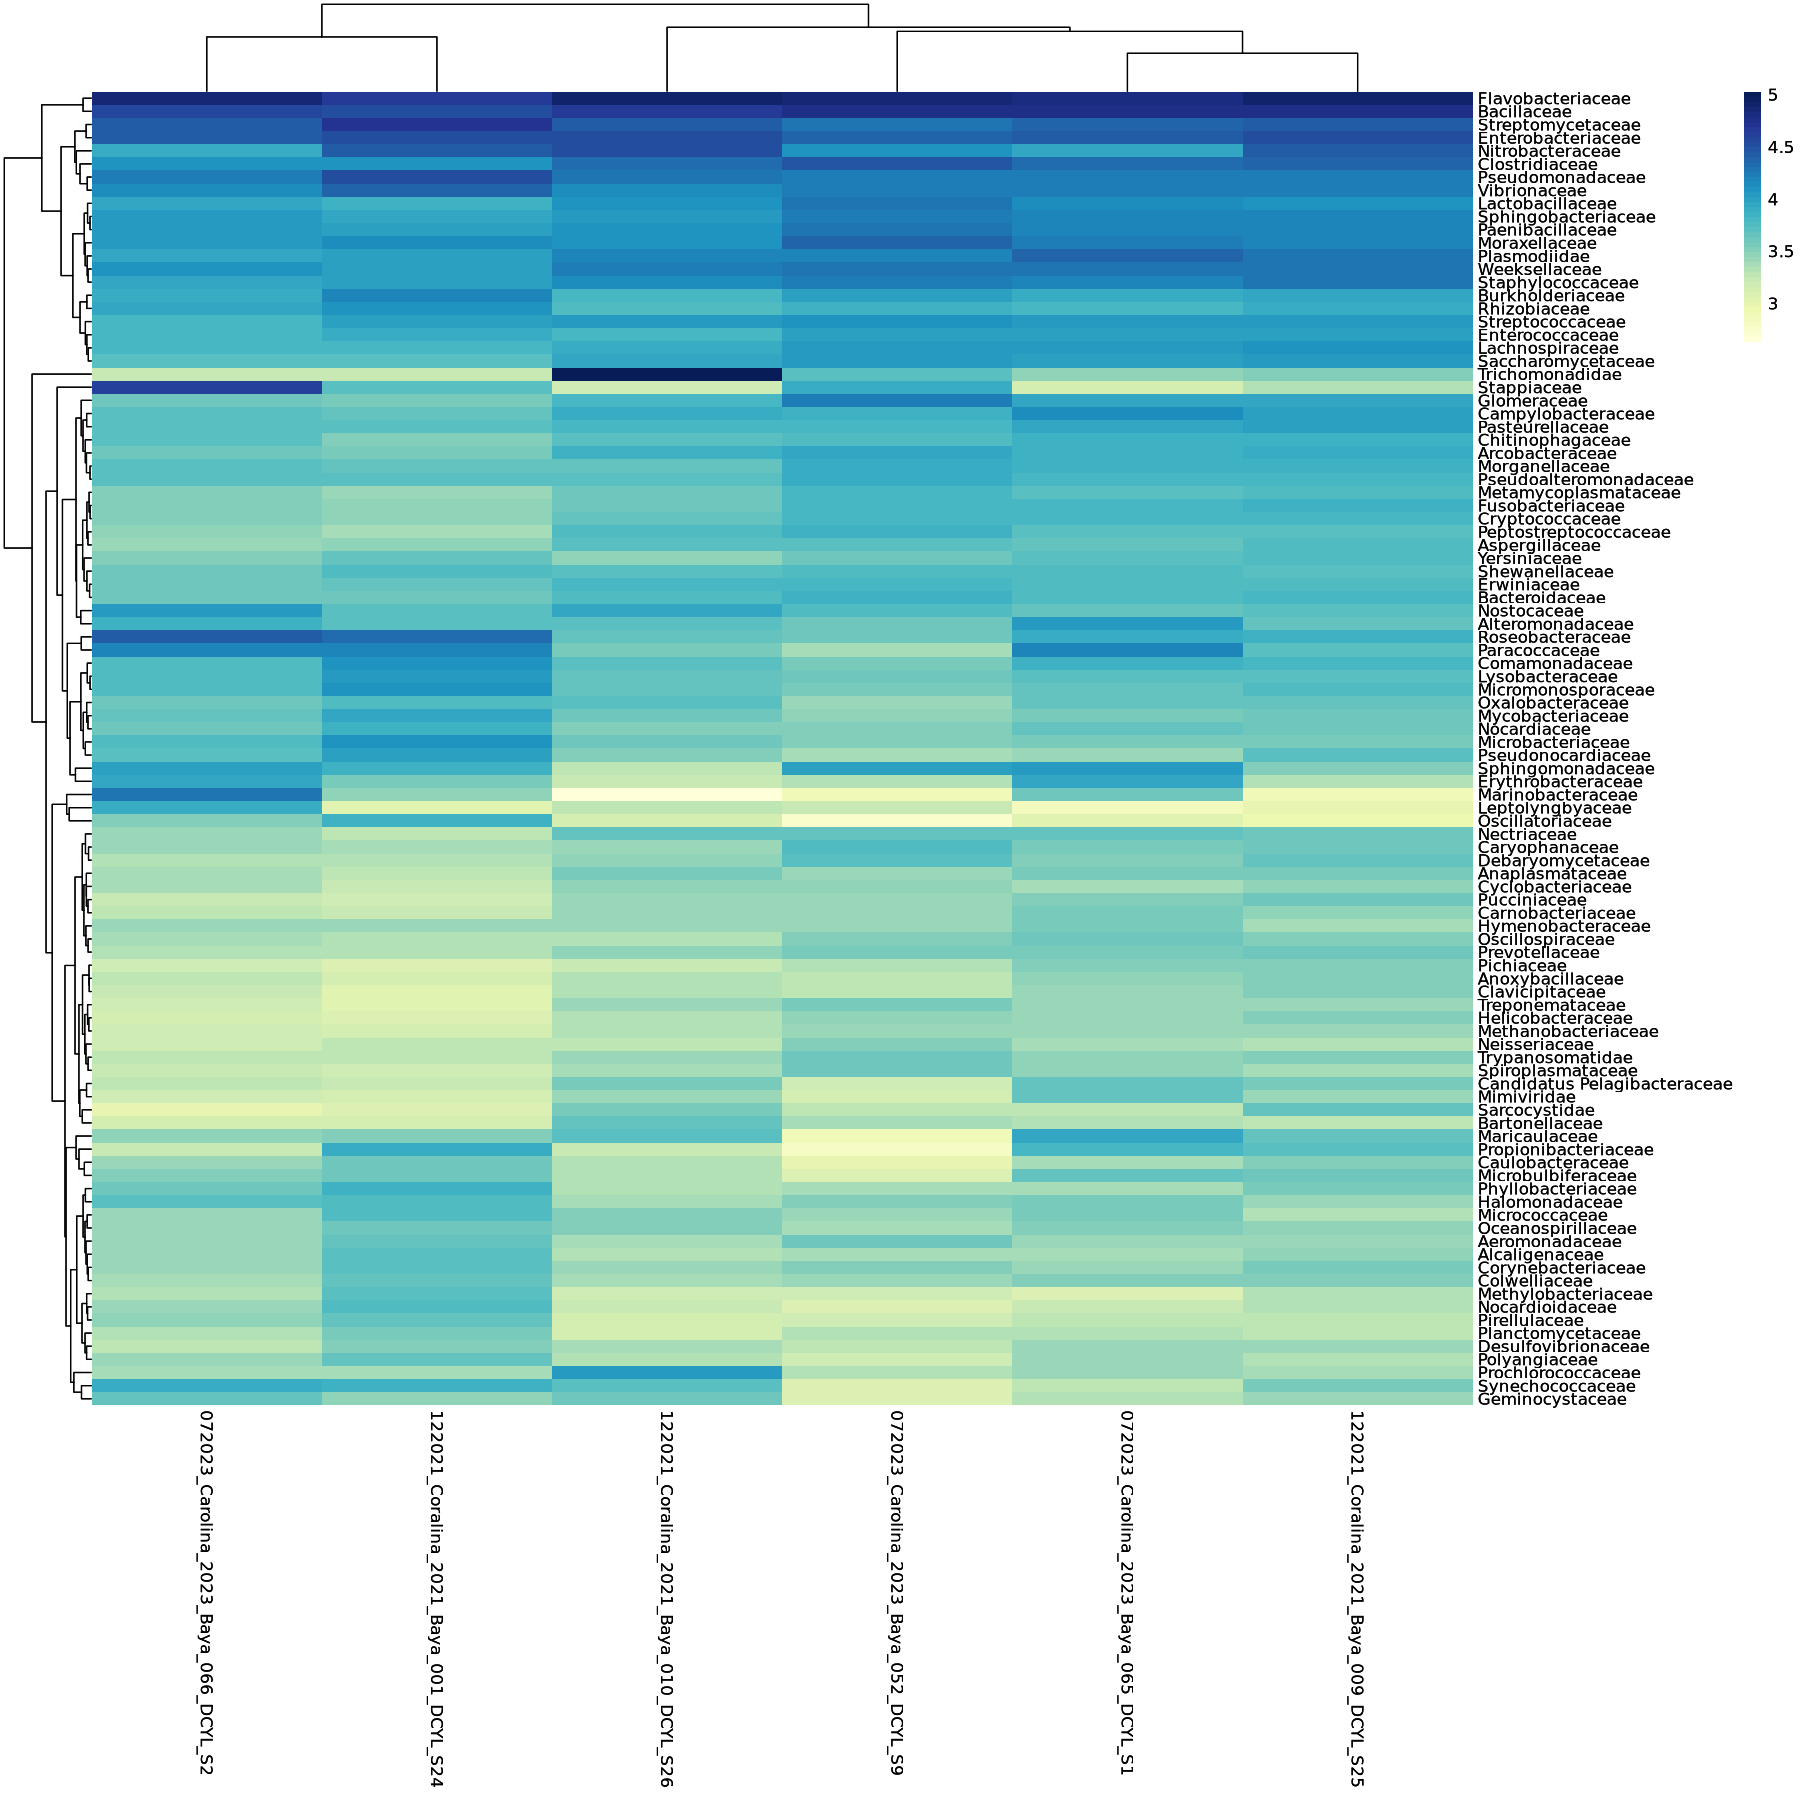

In [33]:
DCYL_100_clean_log_plot <- pheatmap(dcyl_100_clog_counts, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         clustering_distance_rows = "euclidean",
         clustering_distance_cols = "euclidean",
         show_rownames = TRUE,
         fontsize_col = 10,
         #legend_breaks = c(1, 2, 3, 4, 5, max(mcav_50_log_counts)),
         #legend_labels = c("1", "2", "3", "4", "5", "Log abundance\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colors)
DCYL_100_clean_log_plot

In [34]:
ggsave(filename = "dcyl_100_log_heatmap.png", plot = DCYL_100_clean_log_plot, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)